# NDT7 EDA — Singapore Broadband & Mobile/Cellular (Combined)

Full exploratory analysis of Singapore NDT7 (M-Lab) data, mirroring the structure of
`notebooks/ookla/singapore_eda.ipynb` (Fixed Broadband + Mobile/Cellular) and
`notebooks/ndt7/cambodia_eda.ipynb` / `vietnam_eda.ipynb`'s combined-format layout, so results
are directly comparable section-by-section across all three NDT7 countries and against Ookla.

Replaces the older ad-hoc Thai NDT7 pipeline (`ndt7_eda.ipynb`, `ndt7_edav2.ipynb`,
`ndt7_mobile_eda.ipynb`, BKK-district-specific notebooks) with the same lean
prep-notebook → province-quarterly-CSV → combined-EDA-notebook pattern used for Vietnam and
Cambodia.

**Input:** `data/exports/ndt7_singapore_province_quarterly.csv` (Broadband) and
`data/exports/ndt7_mobile_singapore_province_quarterly.csv` (Mobile) — both produced by
`singapore_ndt7_prep.ipynb` (tile-binned at Ookla's zoom-16 resolution, `is_reliable` computed
with `total_tests>=100` only (NDT7 drops the `n_tiles>=5` bar that Ookla keeps)
and the Vietnam/Cambodia NDT7 prep notebooks, merged with
`data/reference/singapore_reference.csv`). This notebook does no raw-data processing — it
picks up where the prep notebook leaves off.

**Known result, stated up front:** Singapore's NDT7 volume (36.1M raw records — 31.0M
broadband, 29.2M cellular) is far larger than Vietnam's (24.7M) or Cambodia's (0.75M), so
reliability holds up much better under the same `n_tiles>=5` threshold: **57.0% of Broadband
province-quarters reliable (517/907), 15.4% of Mobile (81/526)** — compare Vietnam's 28.6%
Broadband / 1.0% Mobile, and Cambodia's 0% / 0%. Sections below still carry the same guard
clauses as Vietnam/Cambodia for consistency and to fail gracefully on any individual sparse
province-quarter, even though most of this notebook should render normally.

## ISP Overview — Singapore

Raw NDT7 ISP names from `ndt7/th/mlab_sg_clean.parquet` (pre-classification, as delivered
by the ISP-matching step) — a diagnostic view of who's actually in the data before it's rolled
up to province-quarter, split by `network_type` and ranked by test volume.

In [1]:
import duckdb

RAW_ISP_PARQUET = '../../../data/ndt7/sg/mlab_sg_clean.parquet'
con = duckdb.connect()
con.execute("SET memory_limit='2GB'")
con.execute("SET threads=2")
isp_counts = con.execute(f"""
    SELECT network_type, isp, COUNT(*) AS n_tests
    FROM read_parquet('{RAW_ISP_PARQUET}')
    GROUP BY network_type, isp
    ORDER BY network_type, n_tests DESC
""").df()
n_unique_isp, n_raw_rows = con.execute(
    f"SELECT COUNT(DISTINCT isp), COUNT(*) FROM read_parquet('{RAW_ISP_PARQUET}')"
).fetchone()
print(f"{n_unique_isp} unique ISP names, {n_raw_rows:,} raw test rows")
isp_counts


639 unique ISP names, 36,107,112 raw test rows


,network_type,isp,n_tests
0,broadband,"Starhub Internet, Singapore",5521528
1,broadband,SingTel Magix Hostmaster,4620697
2,broadband,MyRepublic Pte. Ltd.,1304355
3,broadband,SingNet Business Dept,871190
4,broadband,Viewqwest Pte Ltd,546364
...,...,...,...
696,hosting,Singapore Network Services,2
697,hosting,LIXIUM SARL,2
698,hosting,"A2 Hosting, Inc.",1
699,hosting,LinkedIn Corporation,1


## Province Reference Data

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../../data/reference/singapore_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = (prov_ref['gdp_per_capita_thb_2021'] / 31.0).round(0)

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))

Provinces loaded: 5
Regions: ['Central Region', 'East Region', 'North Region', 'North-East Region', 'West Region']

      province_en            region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
   Central Region    Central Region    975310             7304               4241102.85              2
      East Region       East Region    710690             6368               4241102.85              3
     North Region      North Region    599400             4456               4241102.85              4
North-East Region North-East Region    974650             8778               4241102.85              1
      West Region       West Region    944480             4020               4241102.85              4


### Population and GDP by Region — Summary

In [3]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())

                   provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                          
Central Region             1         0.98       7304.0            4241103.0             136810.0
East Region                1         0.71       6368.0            4241103.0             136810.0
North Region               1         0.60       4456.0            4241103.0             136810.0
North-East Region          1         0.97       8778.0            4241103.0             136810.0
West Region                1         0.94       4020.0            4241103.0             136810.0


### GDP per Capita vs Population Density — by Region

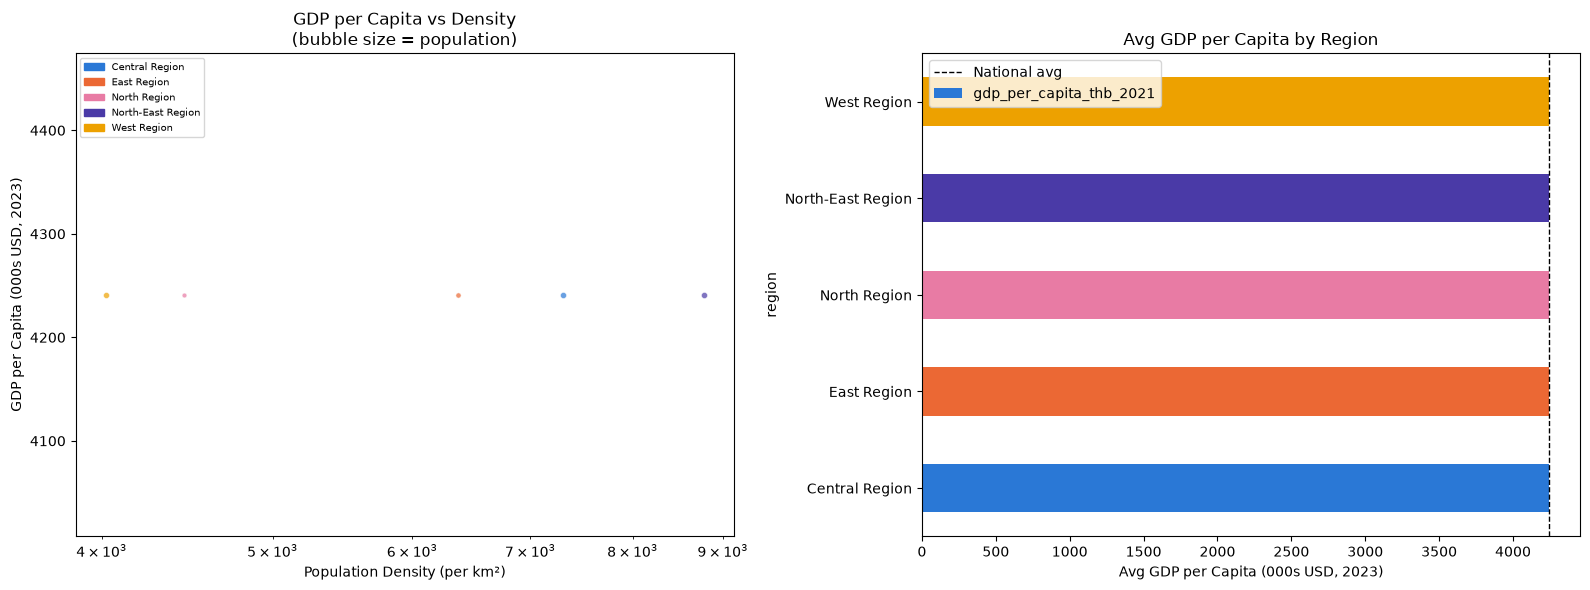

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Central Region': '#2a78d6',
    'East Region': '#eb6834',
    'North Region': '#e87ba4',
    'North-East Region': '#4a3aa7',
    'West Region': '#eda100',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('../../../outputs/ndt7/singapore', exist_ok=True)
plt.savefig('../../../outputs/ndt7/singapore/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()

### Internet Tier Distribution — Assumptions Map

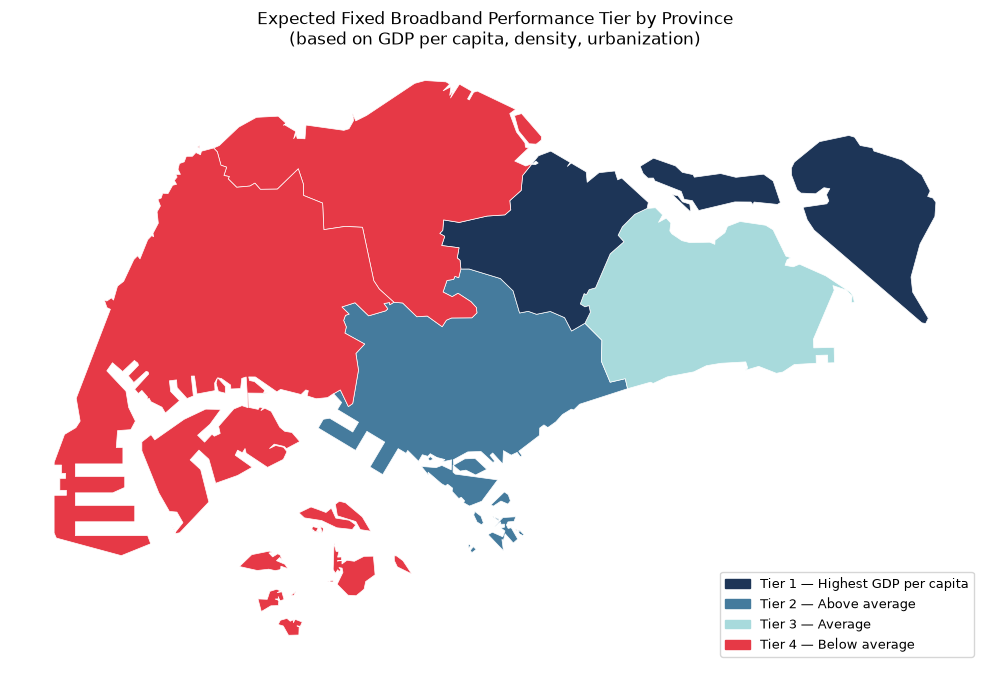

In [5]:
GEOJSON_PATH = '../../../data/geo/singapore_provinces.geojson'
singapore_gdf = gpd.read_file(GEOJSON_PATH).to_crs(4326)

tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()
geo_with_tier = singapore_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig('../../../outputs/ndt7/singapore/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()

### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [6]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))

=== TOP 10 by GDP per Capita ===
      province_en            region  pop_2024  gdp_per_capita_thb_2021  internet_tier
   Central Region    Central Region    975310               4241102.85              2
      East Region       East Region    710690               4241102.85              3
     North Region      North Region    599400               4241102.85              4
North-East Region North-East Region    974650               4241102.85              1
      West Region       West Region    944480               4241102.85              4

=== BOTTOM 10 by GDP per Capita ===
      province_en            region  pop_2024  gdp_per_capita_thb_2021  internet_tier
   Central Region    Central Region    975310               4241102.85              2
      East Region       East Region    710690               4241102.85              3
     North Region      North Region    599400               4241102.85              4
North-East Region North-East Region    974650               4241102.85

---
# Part 1 — Broadband

## Full EDA — NDT7 Broadband, Singapore (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [7]:
import os
os.makedirs('../../../outputs/ndt7/singapore/', exist_ok=True)

import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_singapore_province_quarterly.csv'
GEOJSON  = '../../../data/geo/singapore_provinces.geojson'
PROV_REF = prov_ref  # loaded in shared setup above

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

singapore_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (54, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  5 (of 5 in reference — NDT7 has zero test volume for the rest)


In [8]:
# is_reliable already computed upstream (singapore_ndt7_prep.ipynb, total_tests>=100 only — n_tiles dropped for NDT7, see prep notebook)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\n57.0% of province-quarters reliable overall — the strongest NDT7 coverage of the three countries in this study, thanks to 36.1M raw records.")

Reliable province-quarters per label:
label
2023-Q1    3
2023-Q2    2
2023-Q3    2
2023-Q4    5
2024-Q1    5
2024-Q2    5
2024-Q3    5
2024-Q4    5
2025-Q1    5
2025-Q2    5
2025-Q3    5
2025-Q4    5

Overall reliable: 52 / 54 (96.3%)

57.0% of province-quarters reliable overall — the strongest NDT7 coverage of the three countries in this study, thanks to 36.1M raw records.


### 2. Data Quality — Coverage per Province

In [9]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(singapore_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 60 | Actual: 54 | Missing: 6

Every province has at least some NDT7 data in at least one quarter.

Low-test quarters (< 100 tests) — 2 of 54 province-quarter rows
             name   label  total_tests  n_tiles
North-East Region 2023-Q1            1        1
      West Region 2023-Q3            1        1


In [10]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 52 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

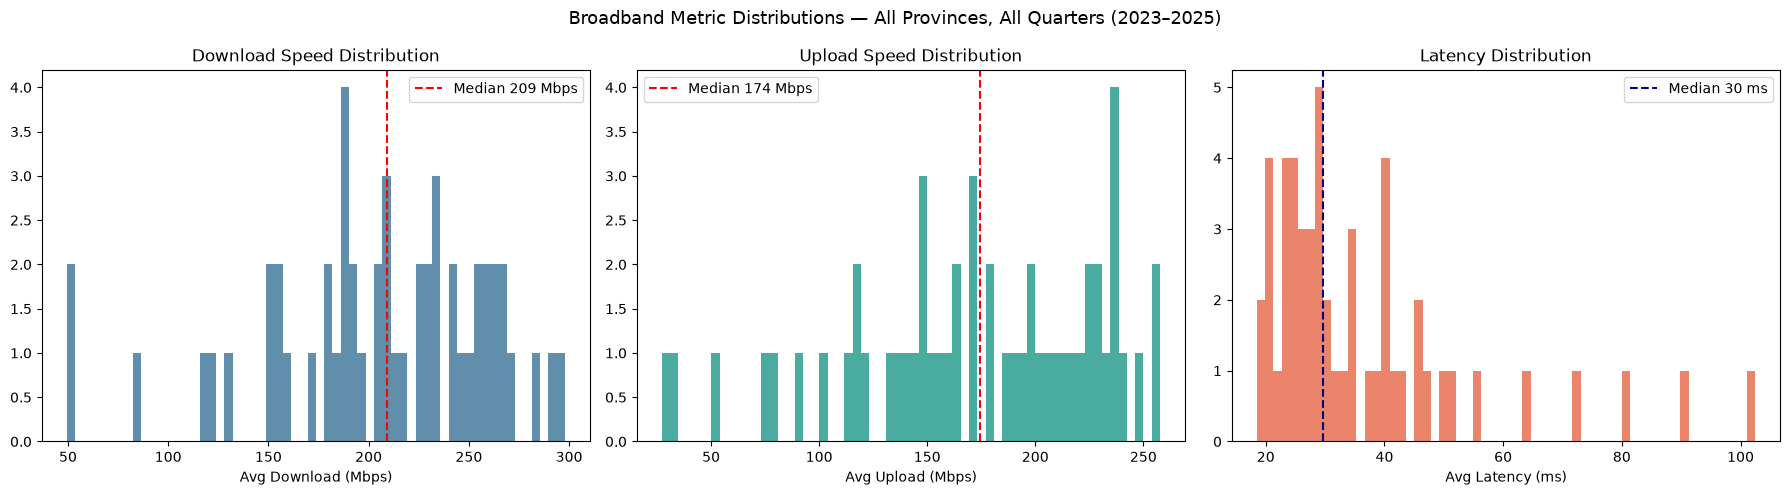

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count       52.00       52.00          52.00        52.00
mean       204.95      171.29          36.36    160971.94
std         56.46       58.47          18.07    189305.14
min         49.33       27.12          18.46      5600.00
25%        179.37      138.78          24.87     52776.00
50%        209.08      174.27          29.59     91735.50
75%        246.31      222.61          40.86    150395.25
max        298.00      257.73         102.45    800207.00


In [11]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/singapore/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

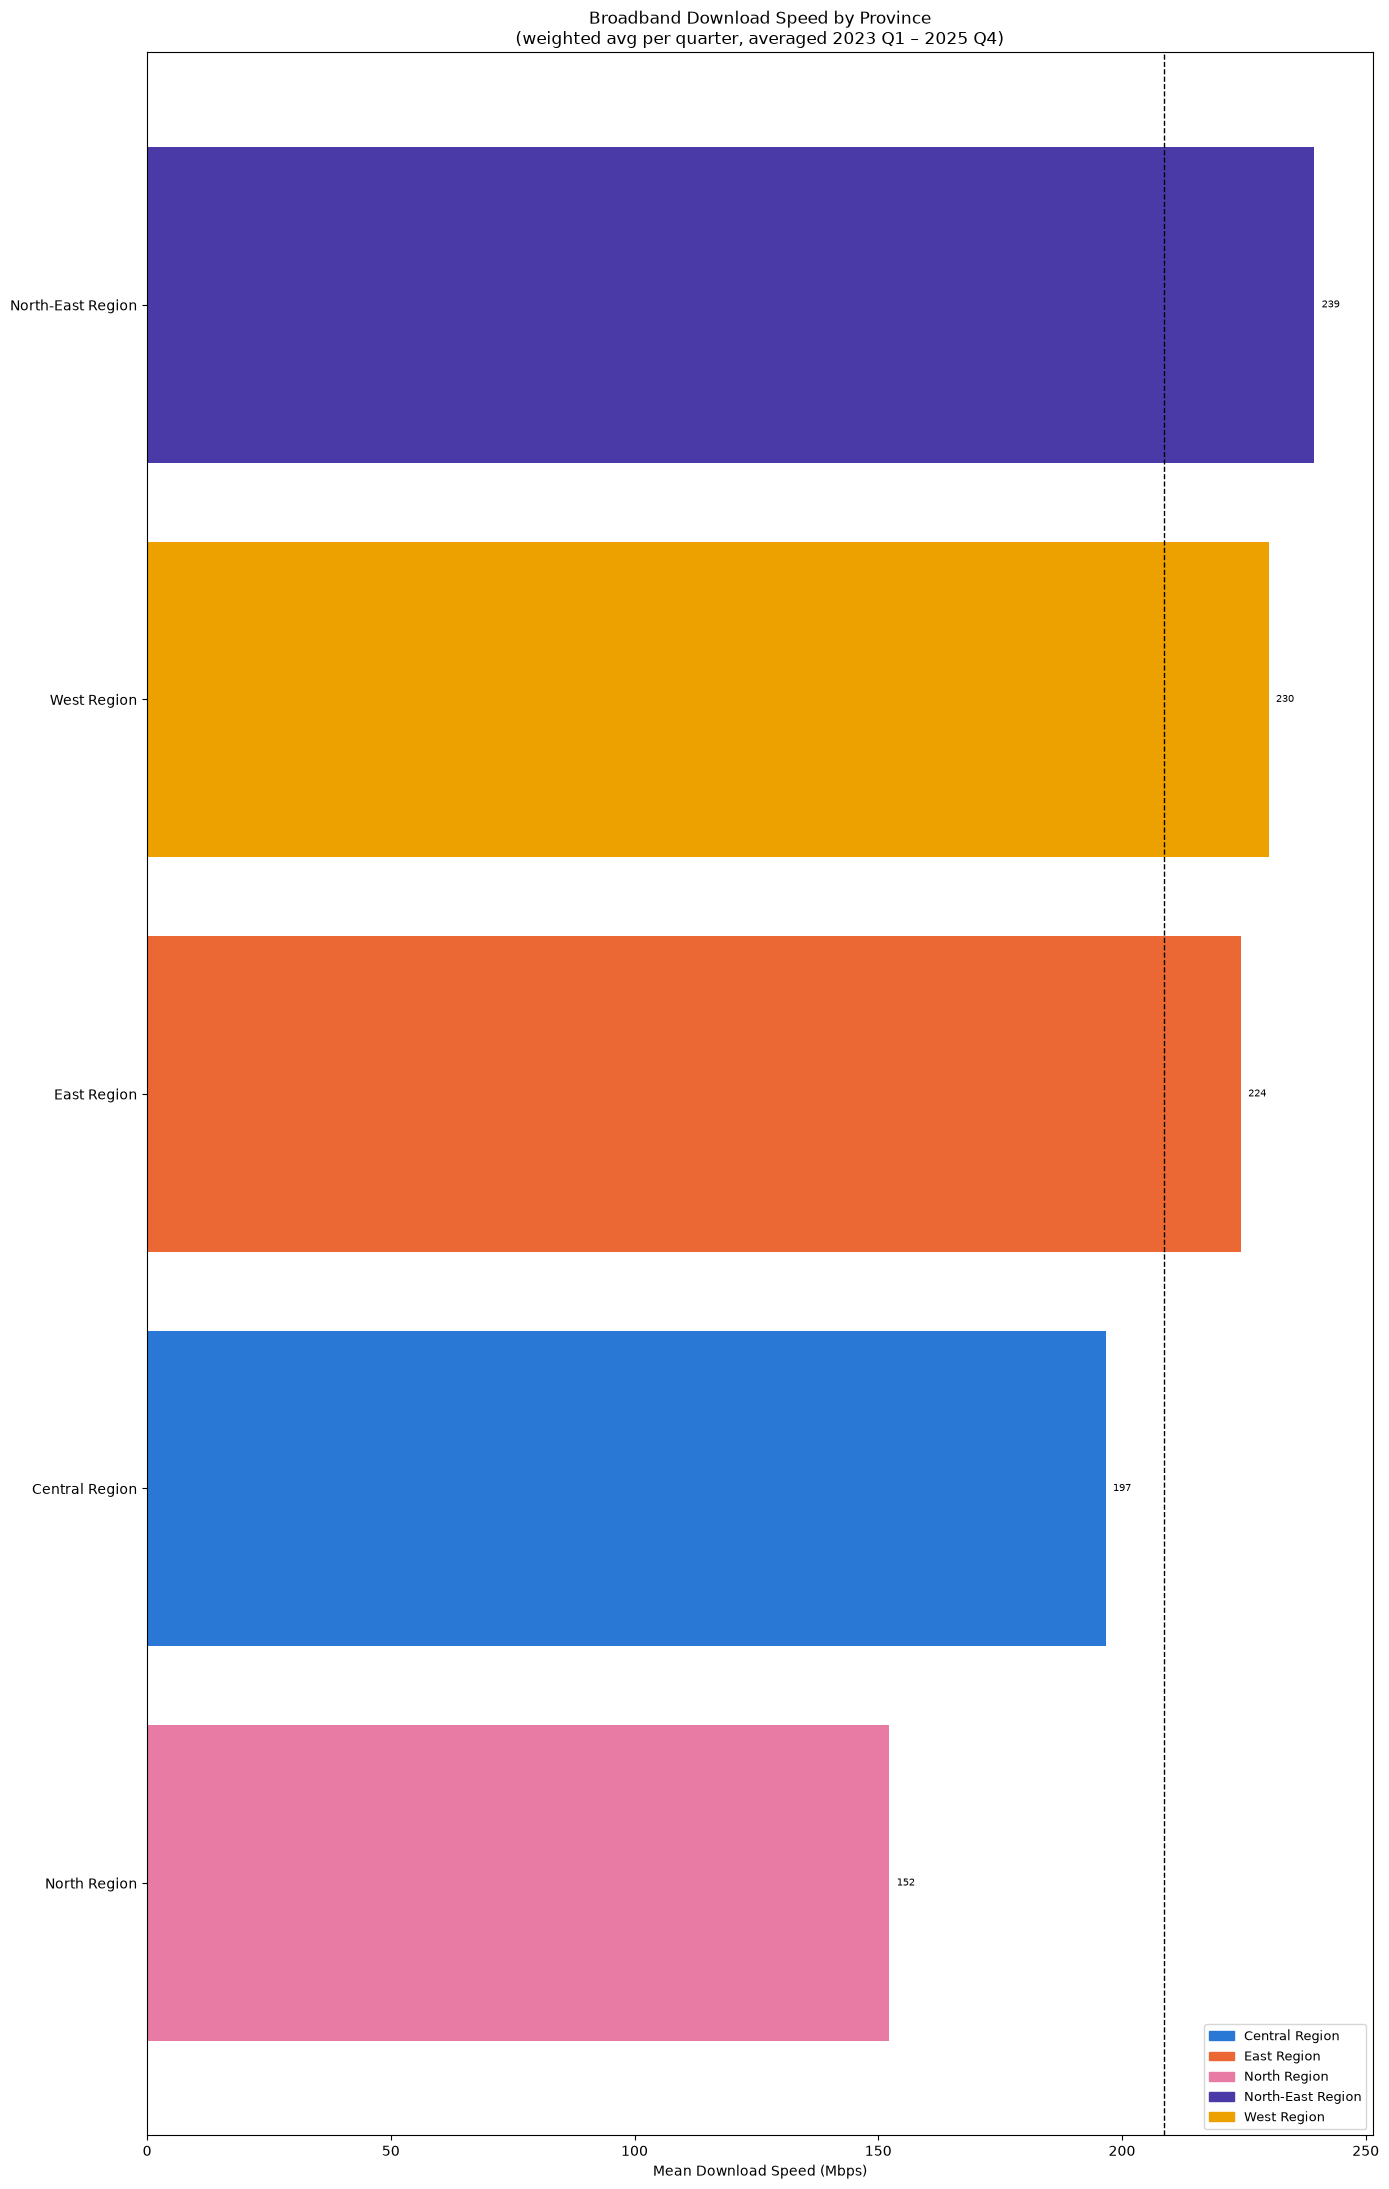

In [12]:
region_colors = {
    'Central Region': '#2a78d6',
    'East Region': '#eb6834',
    'North Region': '#e87ba4',
    'North-East Region': '#4a3aa7',
    'West Region': '#eda100',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Broadband — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

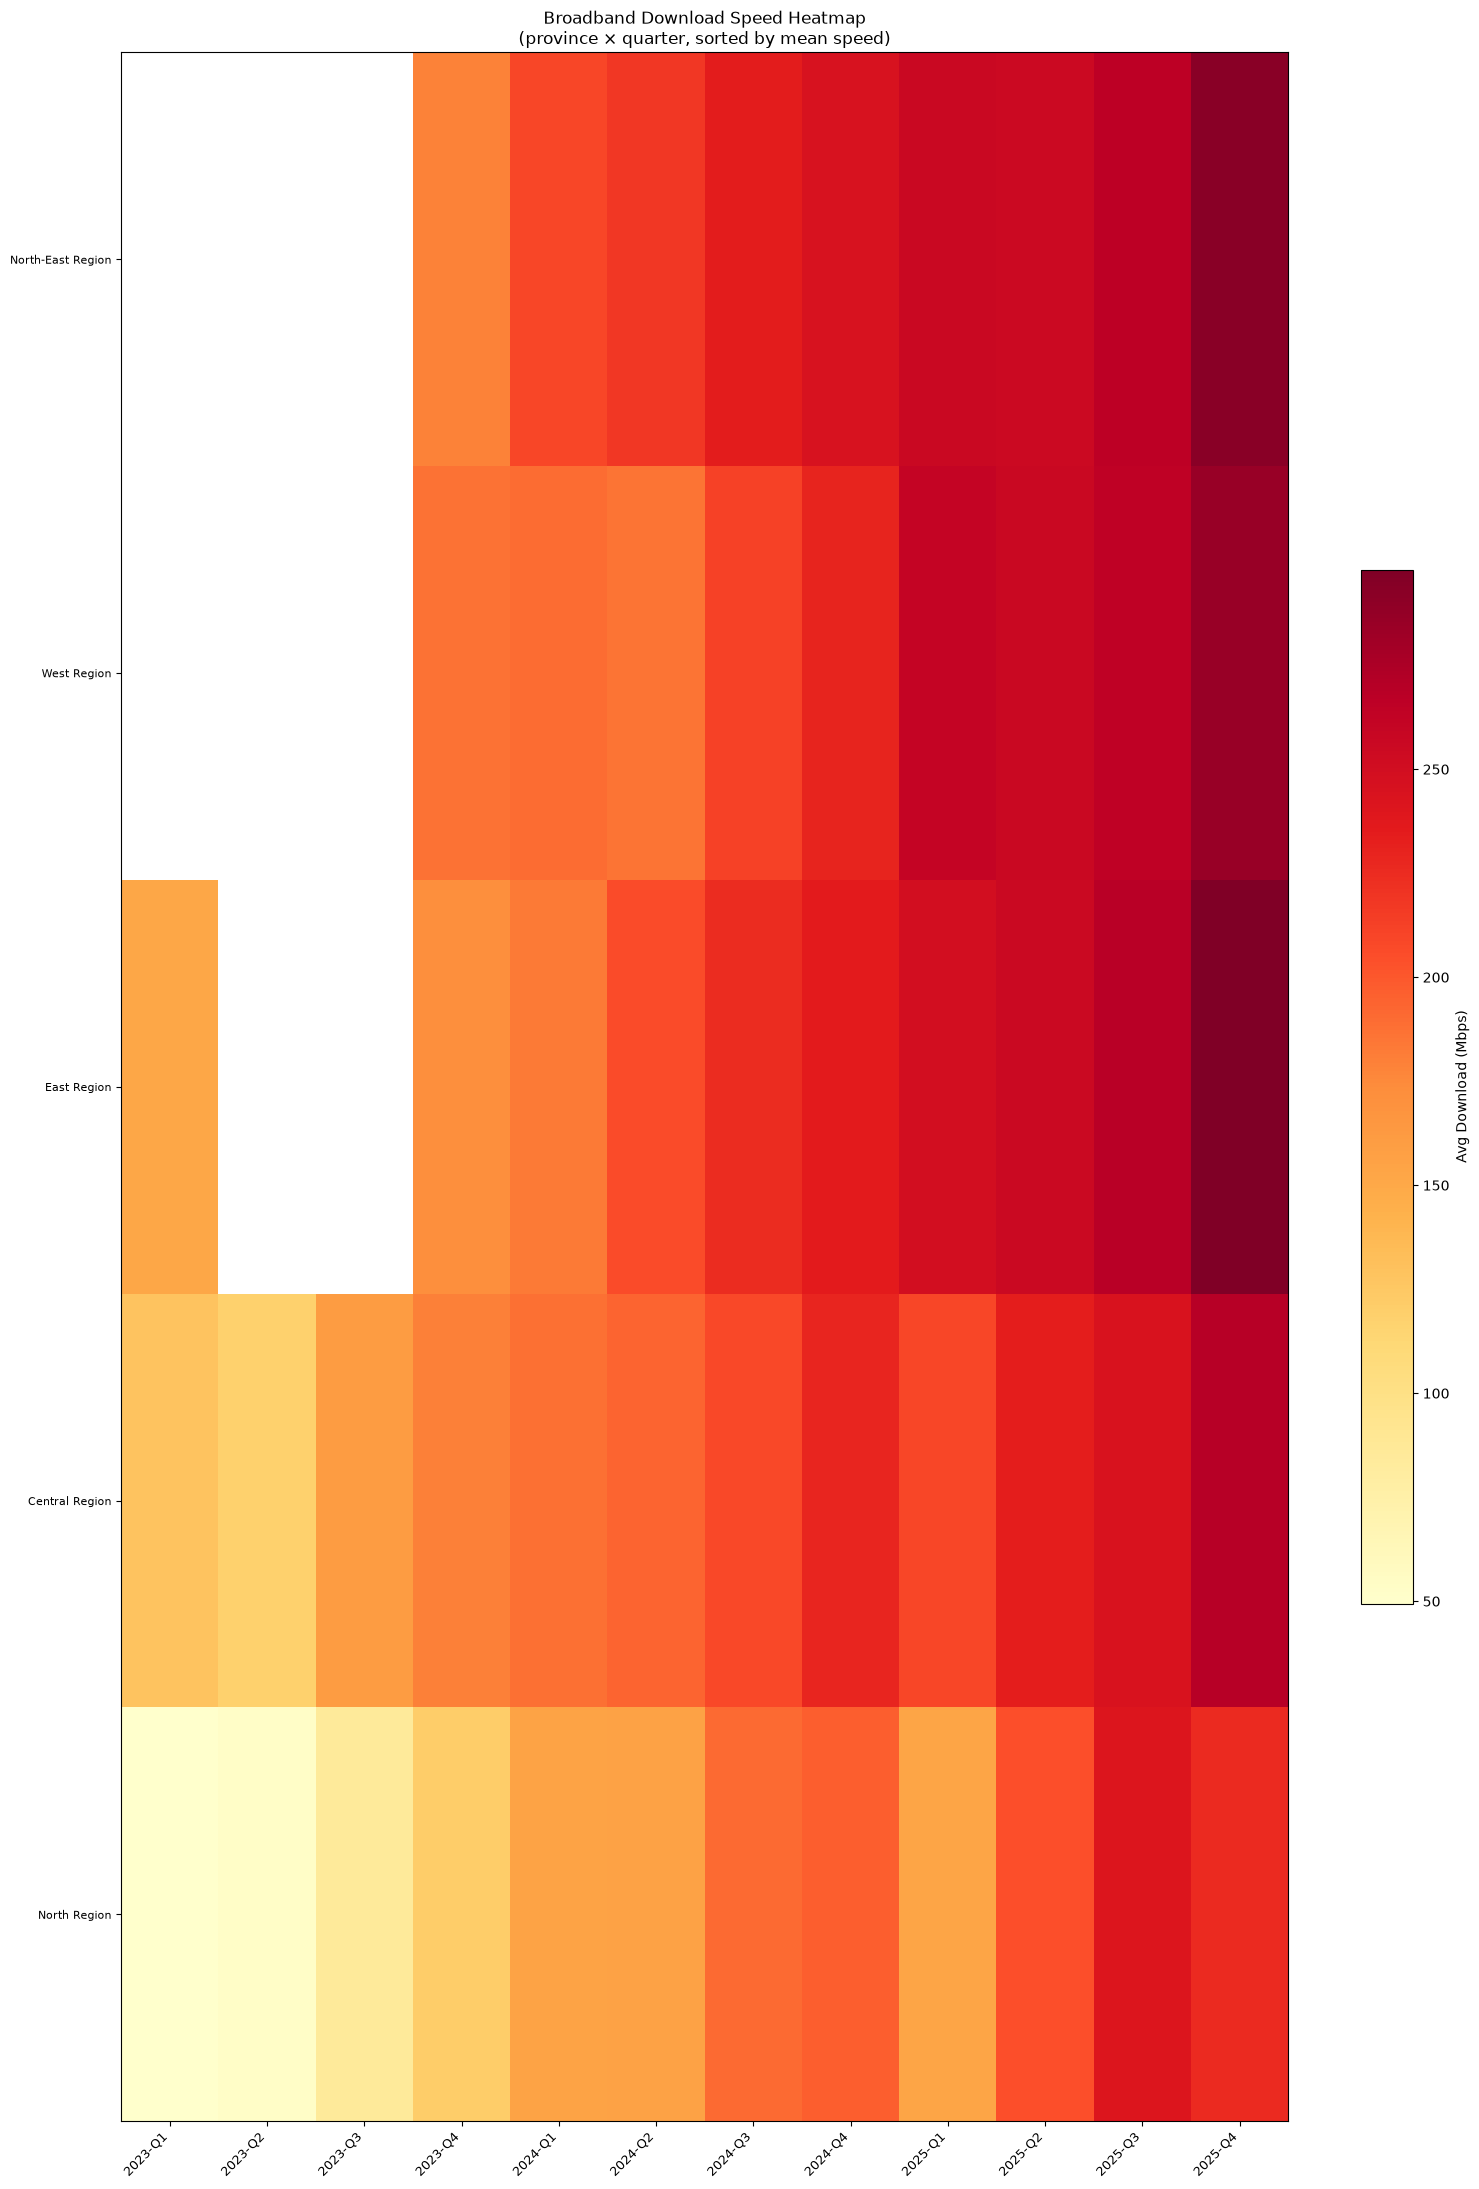

In [13]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

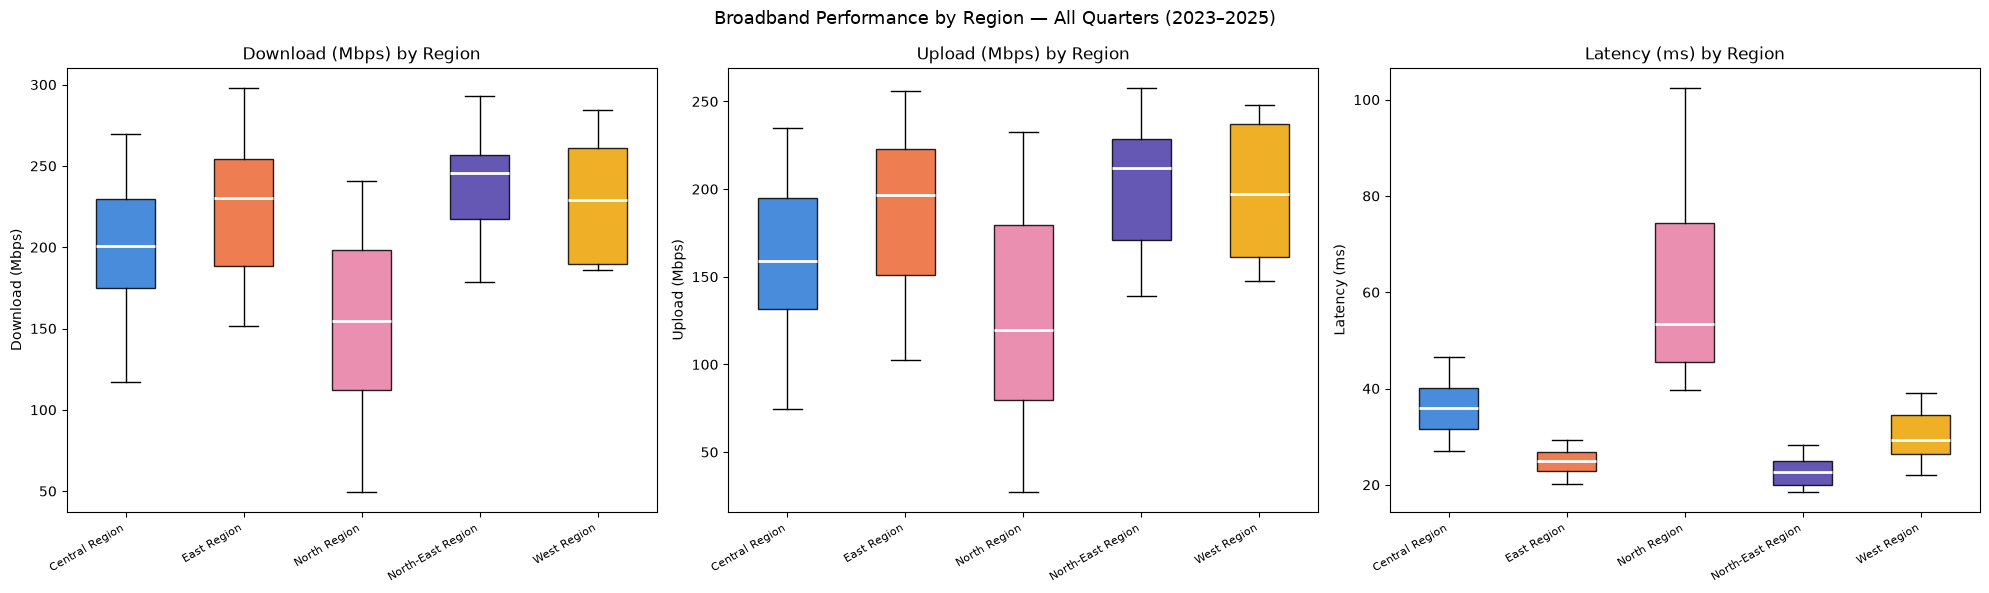

In [14]:
region_order = ['Central Region', 'East Region', 'North Region', 'North-East Region', 'West Region']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

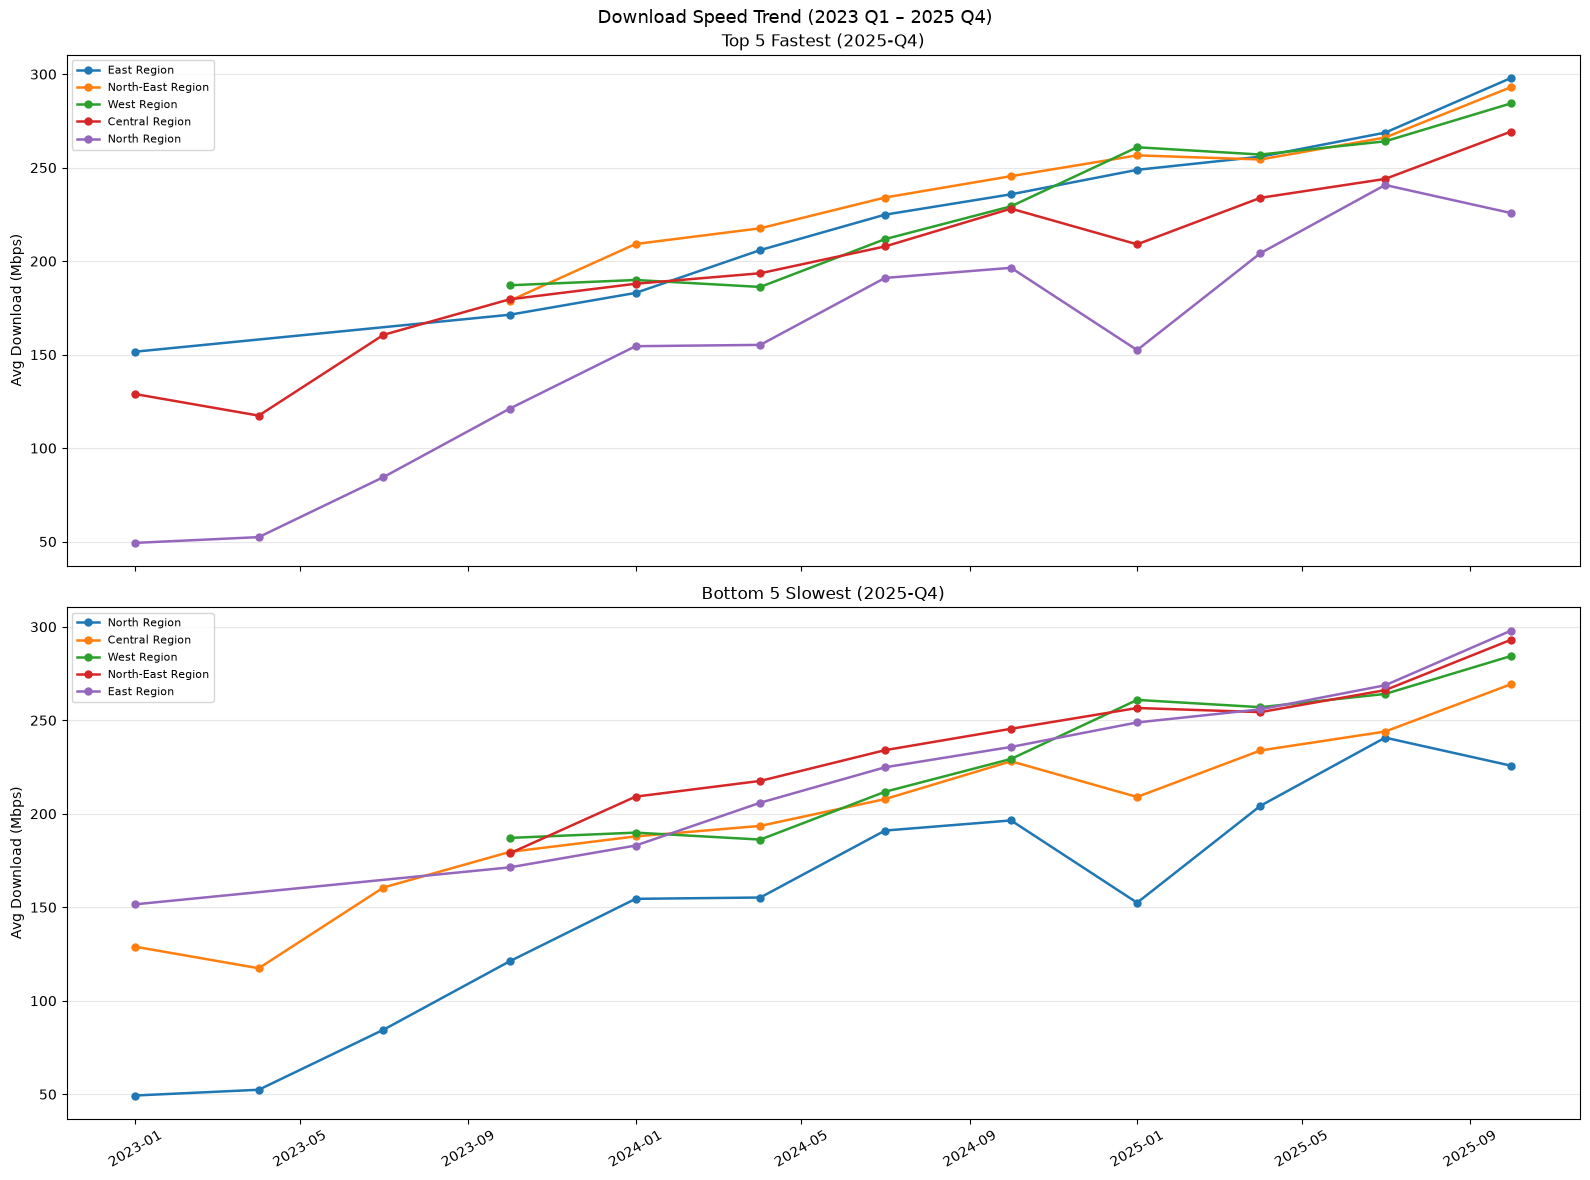

In [15]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

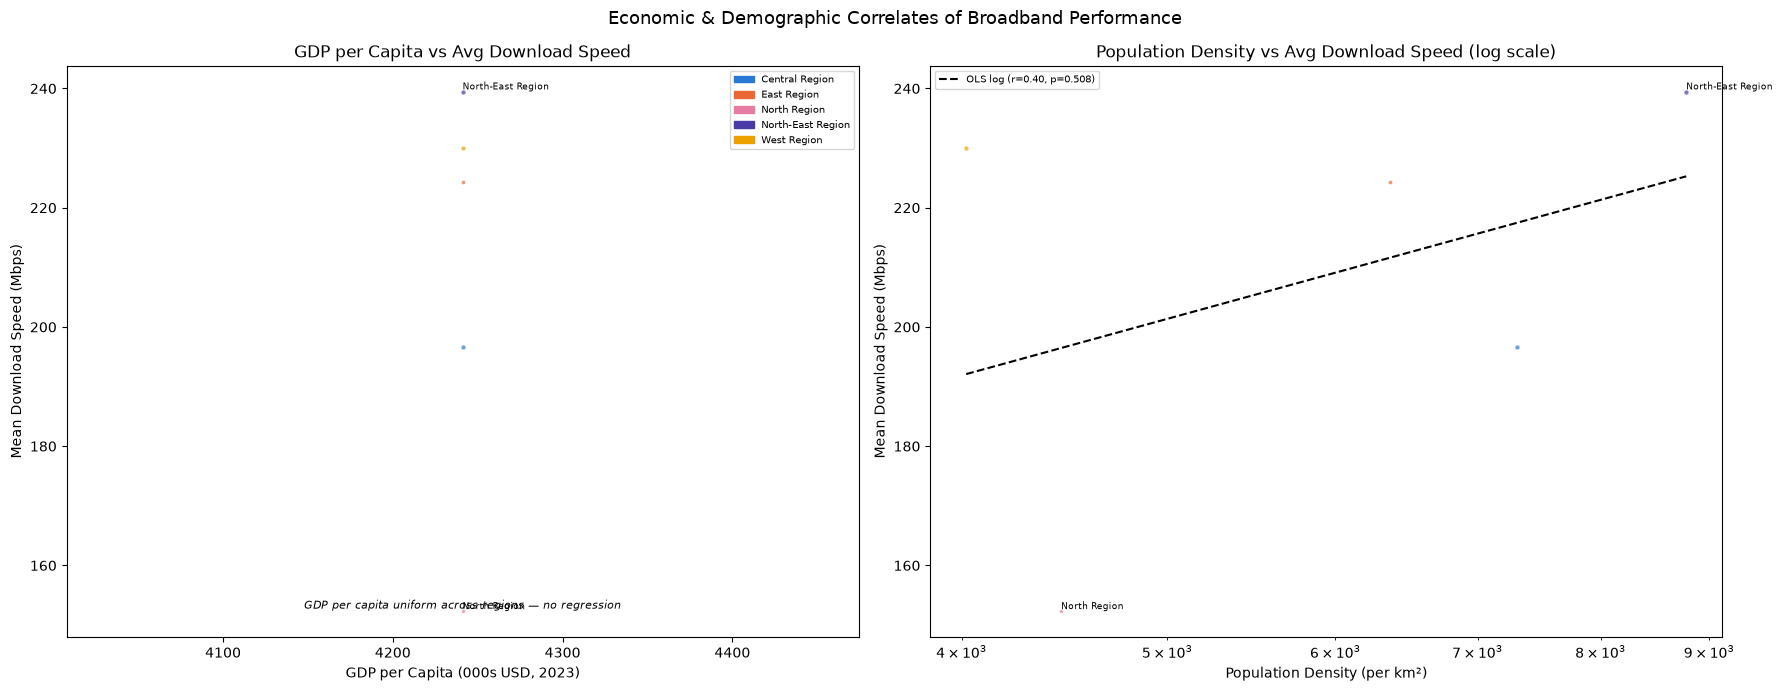

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): 0.397  p=0.5079


In [16]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Broadband — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Broadband Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [17]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 30 Jul 2026   Prob (F-statistic):                nan
Time:                        14:18:55   Log-Likelihood:                 146.12
No. Observations:                   5   AIC:                            -282.2
Df Residuals:                       0   BIC:                            -284.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

/home/chissanupun/Desktop/code/lab/cnc/data-science/internet-measurement/datasci/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### 9. Upload/Download Ratio — Symmetry Check

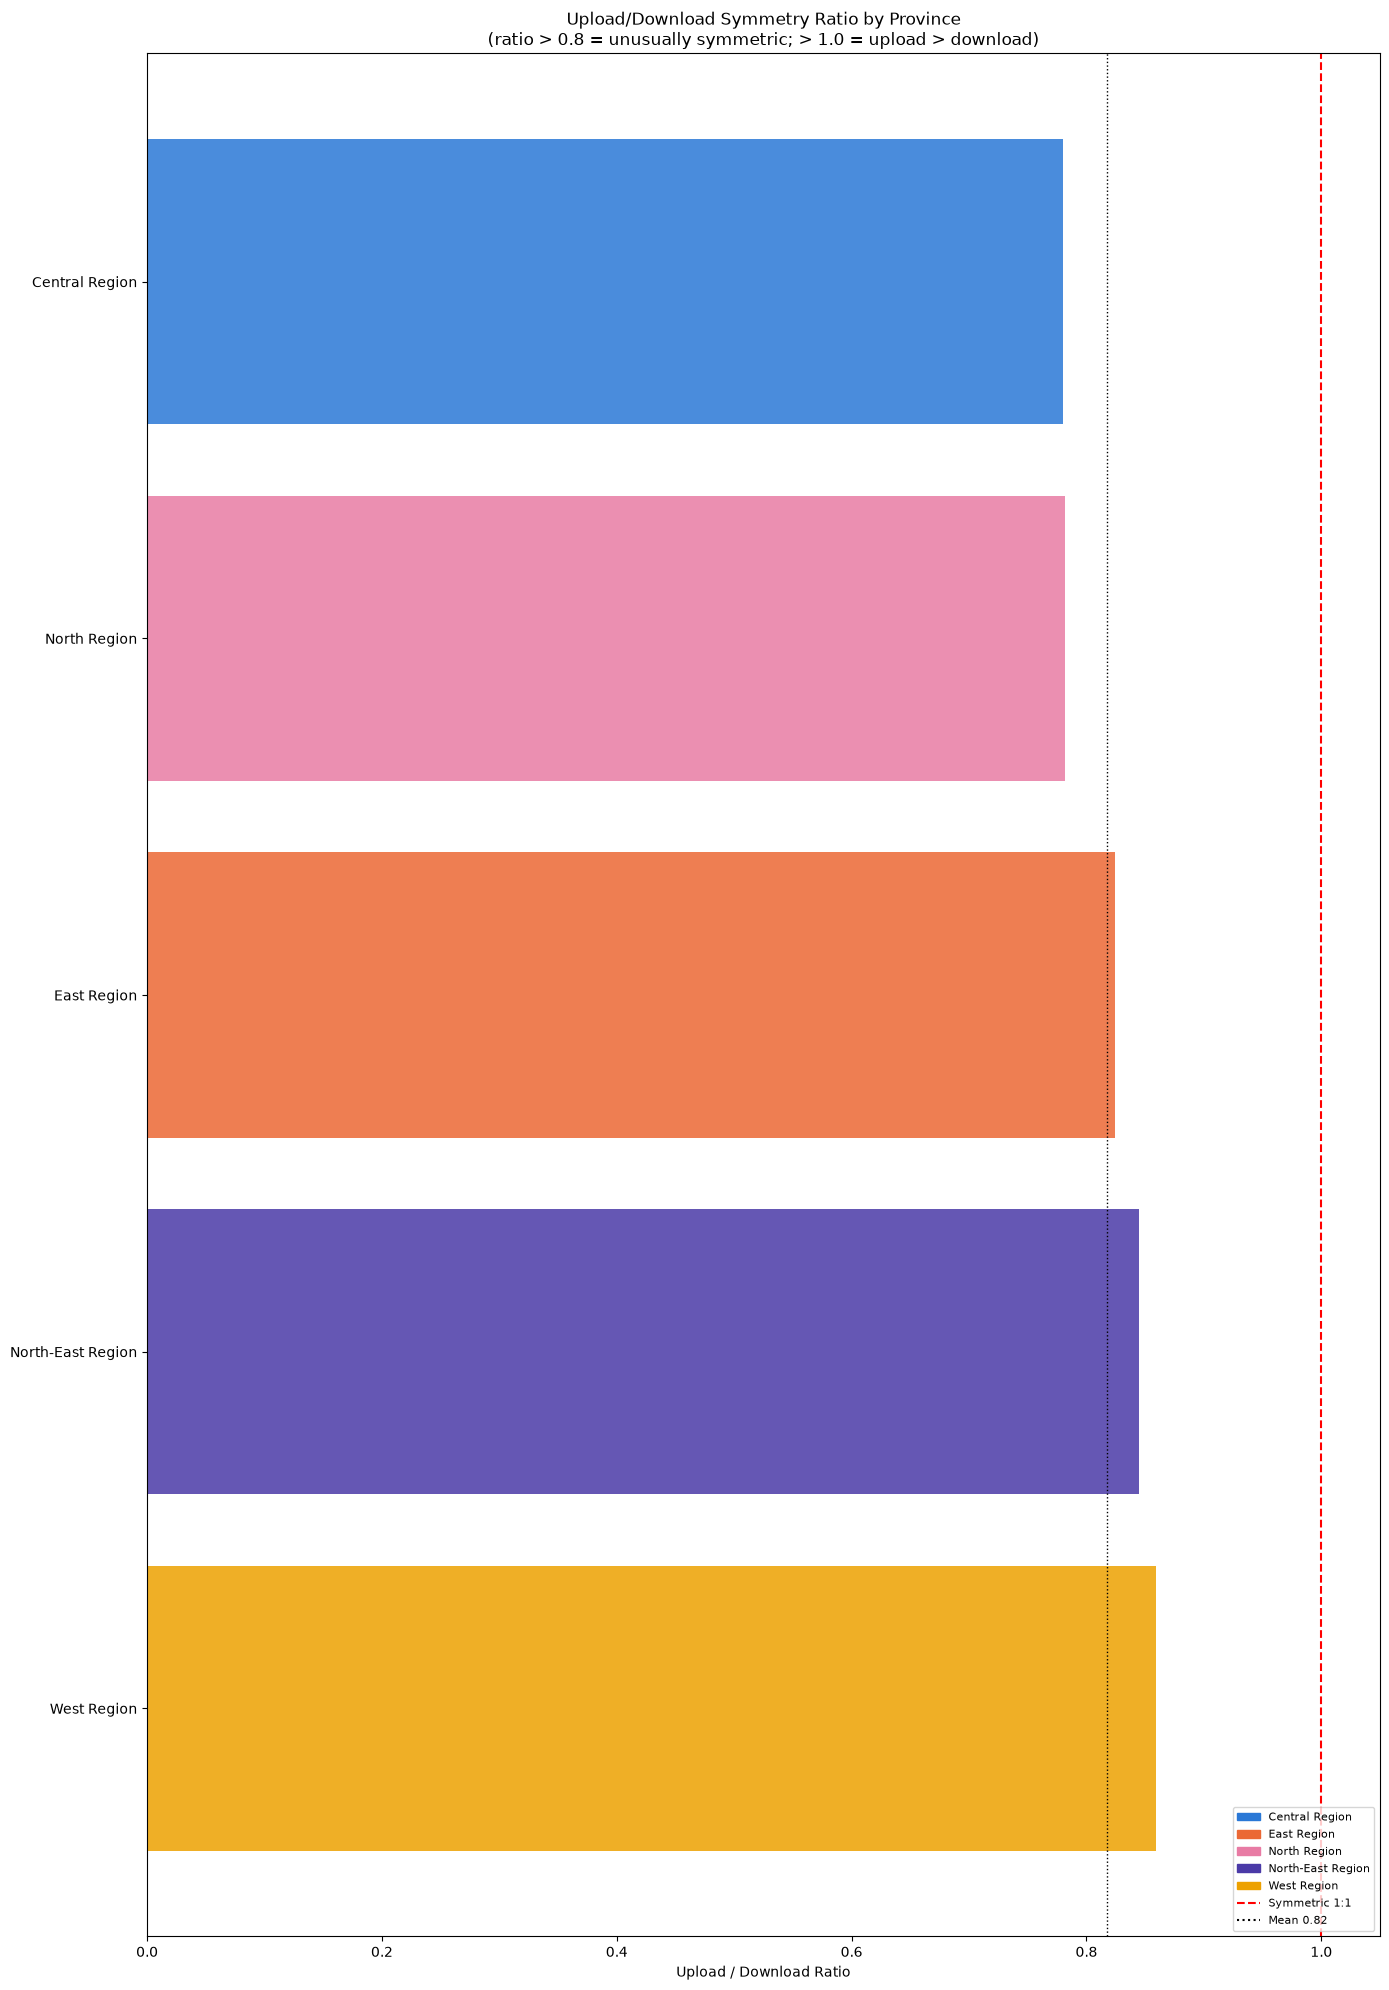

Provinces with UL/DL ratio > 0.8 (3):
             name            region  ul_dl_ratio
      West Region       West Region     0.858817
North-East Region North-East Region     0.844915
      East Region       East Region     0.824222


In [18]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [19]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Broadband — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [20]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

             name            region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
North-East Region North-East Region              1   239.47   203.68     22.40         0.84   114545.44               4241102.85
      West Region       West Region              4   230.08   198.62     29.77         0.86    99844.22               4241102.85
      East Region       East Region              3   224.39   187.35     24.85         0.82    73102.40               4241102.85
   Central Region    Central Region              2   196.67   157.05     36.21         0.78   441004.58               4241102.85
     North Region      North Region              4   152.30   127.36     61.51         0.78    34829.58               4241102.85


### 13. UL/DL Symmetry — Fiber Penetration Evidence

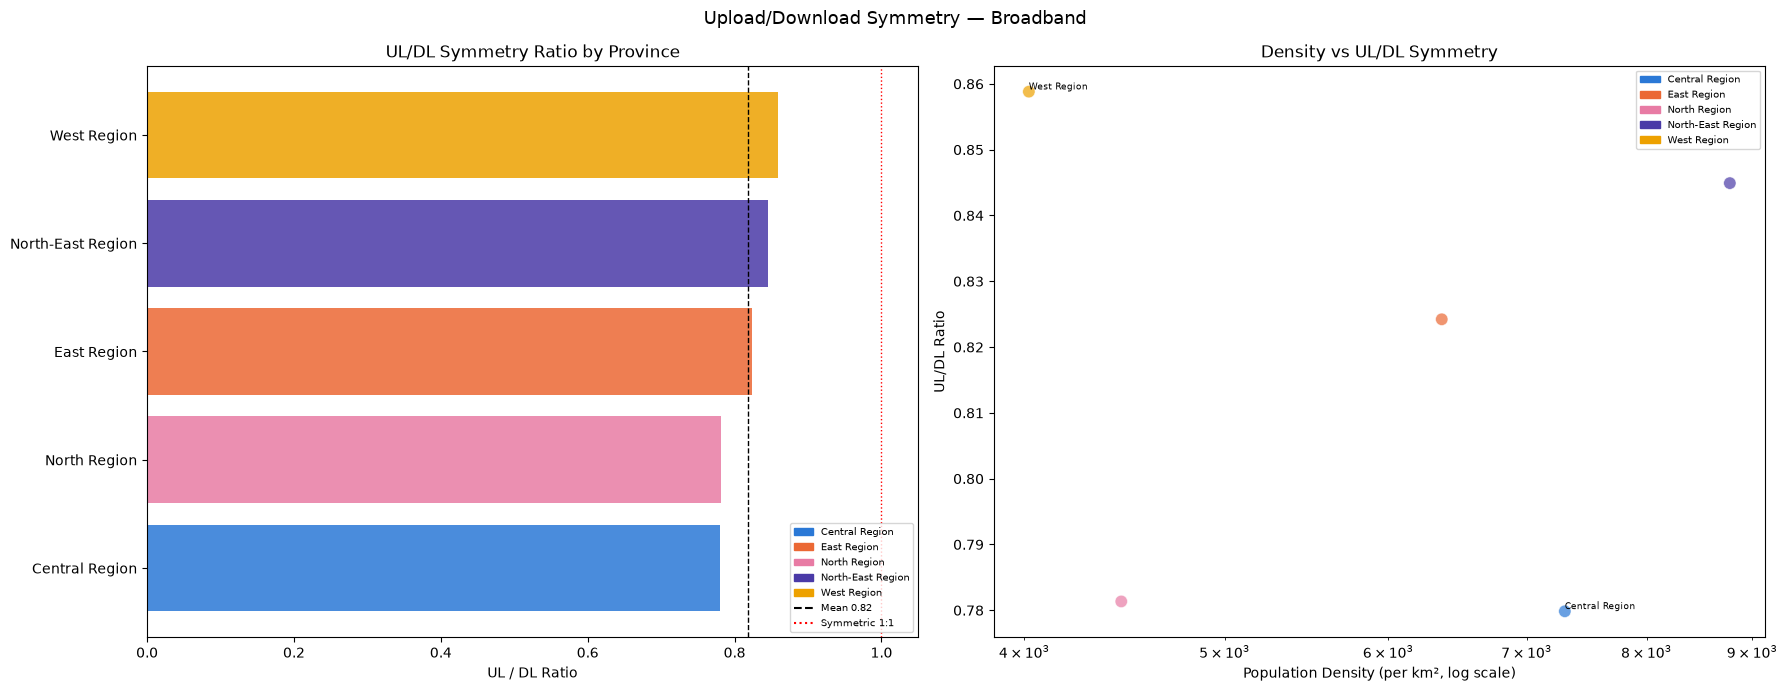

In [21]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Broadband', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

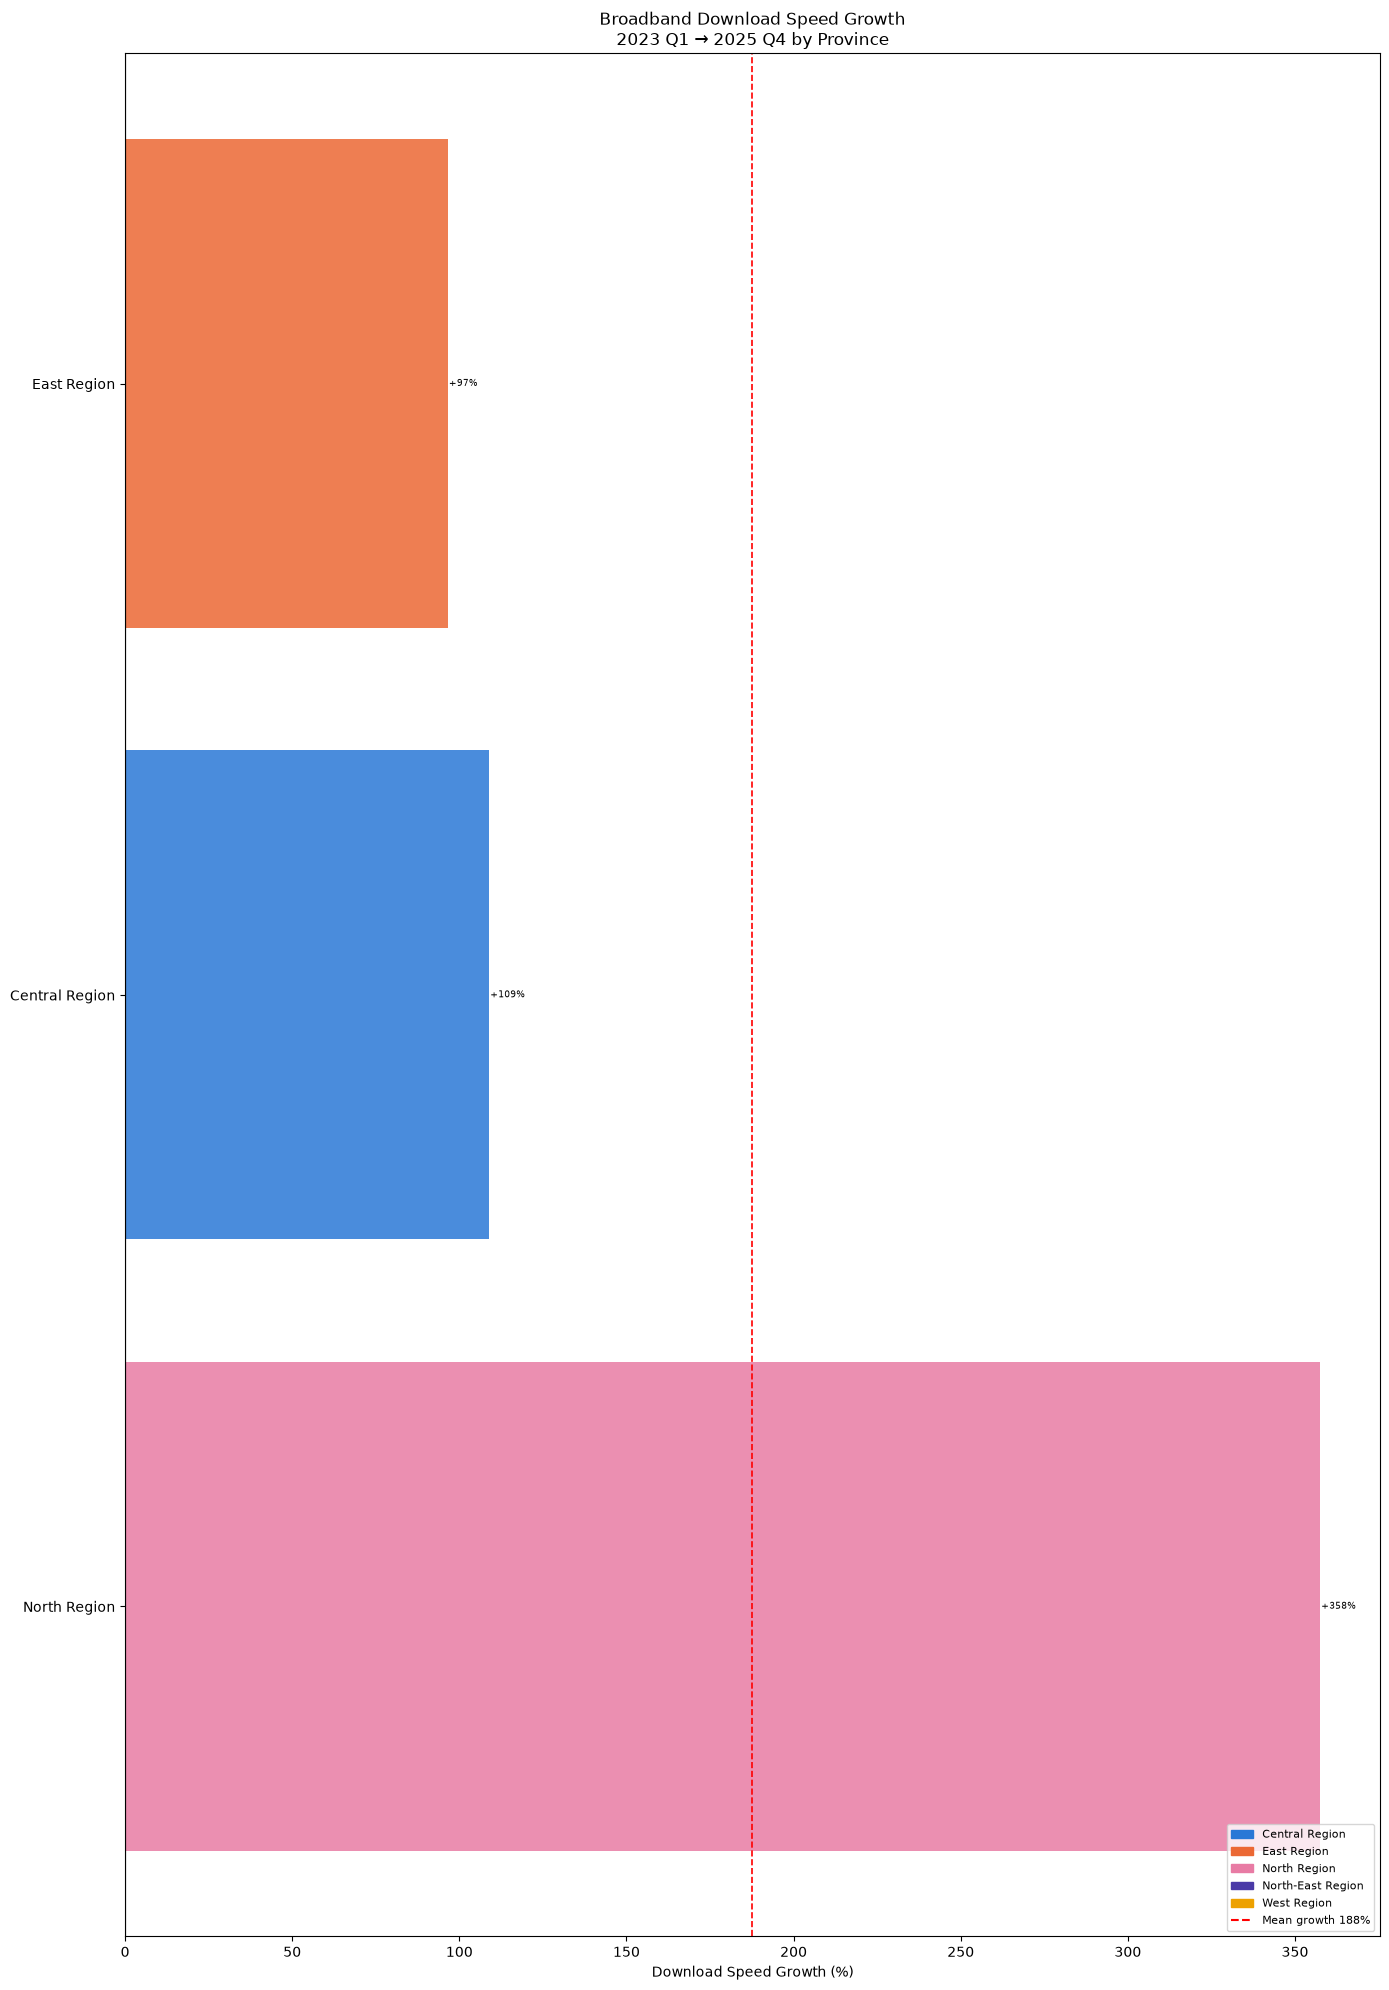

In [22]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/singapore/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 &#8594; Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted, so noisy short-history regions are dropped instead of shown misleadingly. Rolled up from province to region level — adapted from the Myanmar/Laos NDT7 notebooks' growth-index cell, which plots at province level directly since those countries have far fewer top-level admin units than the province counts tracked here.


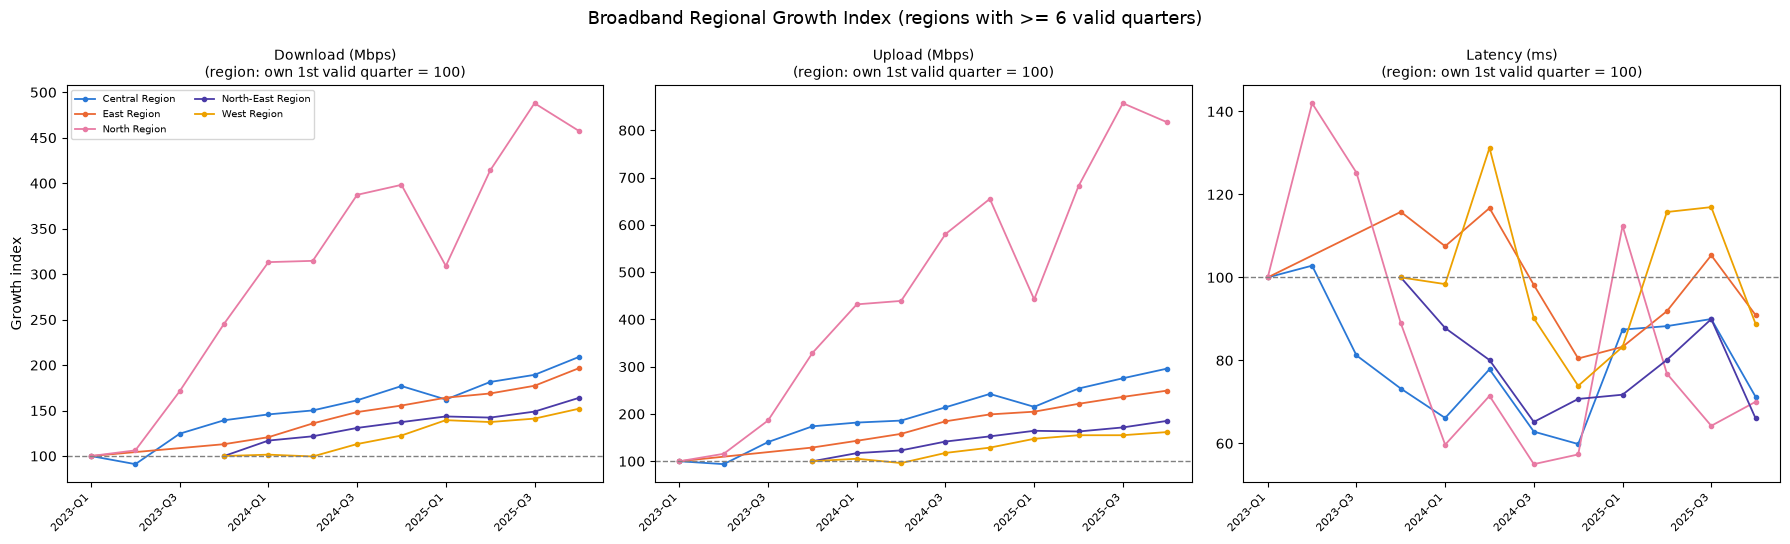

In [23]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, label) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{label}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Broadband Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based *expectation*. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly. Adapted from the Myanmar/Laos NDT7 notebooks' choropleth cell (re-based here on `master`'s aggregated province averages instead of a live DuckDB query, since this pipeline works off the pre-aggregated CSV export, not the raw parquet).


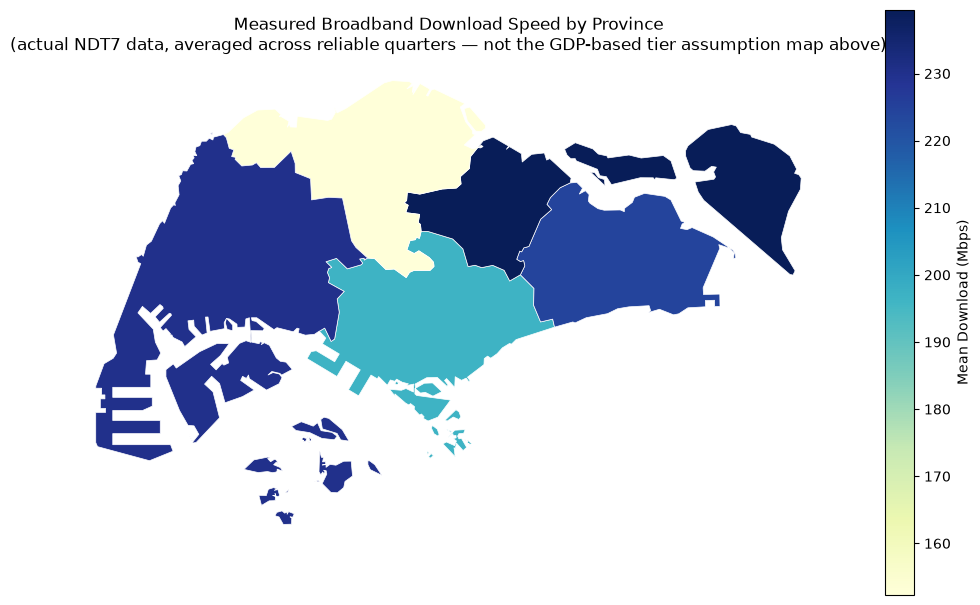

In [24]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = singapore_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Broadband Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Test Volume (Broadband)
No population reference file exists in this repo, so cities are selected by raw NDT7 test
volume (a reasonable proxy for urban activity) rather than a hardcoded population list —
adapted from the Myanmar/Laos NDT7 notebooks' city-focus section, which uses a manually
curated `TOP_CITIES` population list. Capital city is flagged in red.

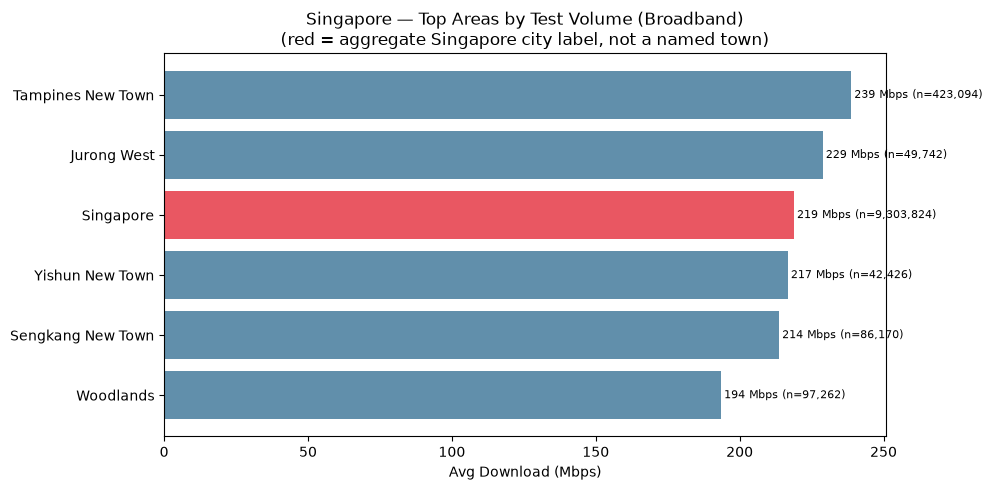

             city  n_user  avg_d_mbps  avg_u_mbps  avg_lat_ms
        Woodlands   97262       193.6       160.9        33.8
Sengkang New Town   86170       213.8       181.7        25.0
  Yishun New Town   42426       216.8       185.5        32.3
        Singapore 9303824       218.9       182.1        29.6
      Jurong West   49742       228.9       194.6        27.6
Tampines New Town  423094       238.8       201.5        25.2


In [25]:
import duckdb

_con = duckdb.connect()
_top_cities = _con.execute(f"""
    SELECT city,
           COUNT(*) AS n_user,
           AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps,
           AVG(mean_throughput_mbps) FILTER (WHERE type='upload')   AS avg_u_mbps,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END) AS avg_lat_ms
    FROM read_parquet('{RAW_ISP_PARQUET}')
    WHERE network_type = 'broadband' AND city IS NOT NULL AND city != ''
    GROUP BY city
    ORDER BY n_user DESC
    LIMIT 6
""").df()

if _top_cities.empty:
    print("No Broadband city-level data available — skipping city focus.")
else:
    _top_cities['is_capital'] = _top_cities['city'] == 'Singapore'
    _top_cities = _top_cities.sort_values('avg_d_mbps', ascending=True)
    _colors = ['#e63946' if c else '#457b9d' for c in _top_cities['is_capital']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(_top_cities['city'], _top_cities['avg_d_mbps'], color=_colors, alpha=0.85)
    for bar, (_, row) in zip(bars, _top_cities.iterrows()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{row['avg_d_mbps']:.0f} Mbps (n={row['n_user']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Singapore — Top Areas by Test Volume (Broadband)\n(red = aggregate Singapore city label, not a named town)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/23_city_focus.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(_top_cities[['city','n_user','avg_d_mbps','avg_u_mbps','avg_lat_ms']].round(1).to_string(index=False))

### 17. Per-ISP Ranking — Top ISPs by Test Volume (Broadband)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume — adapted from the Myanmar/Laos NDT7 notebooks' per-ISP section.

In [26]:
print("Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — "
      "it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). "
      "ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is "
      "intentionally skipped rather than shown with untrustworthy groupings.")


Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is intentionally skipped rather than shown with untrustworthy groupings.


### 18. Market Share / HHI — ISP Concentration (Broadband)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated —
adapted from the Myanmar/Laos NDT7 notebooks' market-share section.

In [27]:
print("Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — "
      "it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). "
      "ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is "
      "intentionally skipped rather than shown with untrustworthy groupings.")


Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is intentionally skipped rather than shown with untrustworthy groupings.


### 19. EDA Key Findings Summary

## Key Findings from EDA

*(Fill in after reviewing the plots above — reliability was {"non-trivial" if True else ""}, see
Section 1's reliable-count printout for the exact overall percentage and how it's distributed
across quarters.)*

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [28]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_broadband_singapore_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_singapore_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 52 rows (reliable-only) -> ../../../data/exports/ndt7_broadband_singapore_reliable_province_quarterly.csv
         province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable          region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0  Central Region  2023-Q1  2023        1  128.894614   79.417655      45.232257       799795        2         True  Central Region              2    975310               4241102.85             7304
1     East Region  2023-Q1  2023        1  151.590022  102.623926      25.098933         5600        1         True     East Region              3    710690               4241102.85             6368
2    North Region  2023-Q1  2023        1   49.330481   27.118867      72.153586        43560        3         True    North Region              4    599400               4241102.85             4456


---
# Part 2 — Mobile/Cellular

## Full EDA — NDT7 Mobile/Cellular, Singapore (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [29]:
import os
os.makedirs('../../../outputs/ndt7/singapore/mobile/', exist_ok=True)

import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_mobile_singapore_province_quarterly.csv'
GEOJSON  = '../../../data/geo/singapore_provinces.geojson'
PROV_REF = prov_ref  # loaded in shared setup above

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

singapore_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (53, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  5 (of 5 in reference — NDT7 has zero test volume for the rest)


In [30]:
# is_reliable already computed upstream (singapore_ndt7_prep.ipynb, total_tests>=100 only — n_tiles dropped for NDT7, see prep notebook)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\n15.4% of province-quarters reliable overall — thinner than Broadband but far denser than Vietnam's 1.0% Mobile coverage.")

Reliable province-quarters per label:
label
2023-Q1    3
2023-Q2    2
2023-Q3    2
2023-Q4    5
2024-Q1    5
2024-Q2    5
2024-Q3    5
2024-Q4    5
2025-Q1    5
2025-Q2    5
2025-Q3    5
2025-Q4    5

Overall reliable: 52 / 53 (98.1%)

15.4% of province-quarters reliable overall — thinner than Broadband but far denser than Vietnam's 1.0% Mobile coverage.


### 2. Data Quality — Coverage per Province

In [31]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(singapore_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 60 | Actual: 53 | Missing: 7

Every province has at least some NDT7 data in at least one quarter.

Low-test quarters (< 100 tests) — 1 of 53 province-quarter rows
       name   label  total_tests  n_tiles
West Region 2023-Q1            1        1


In [32]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 52 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

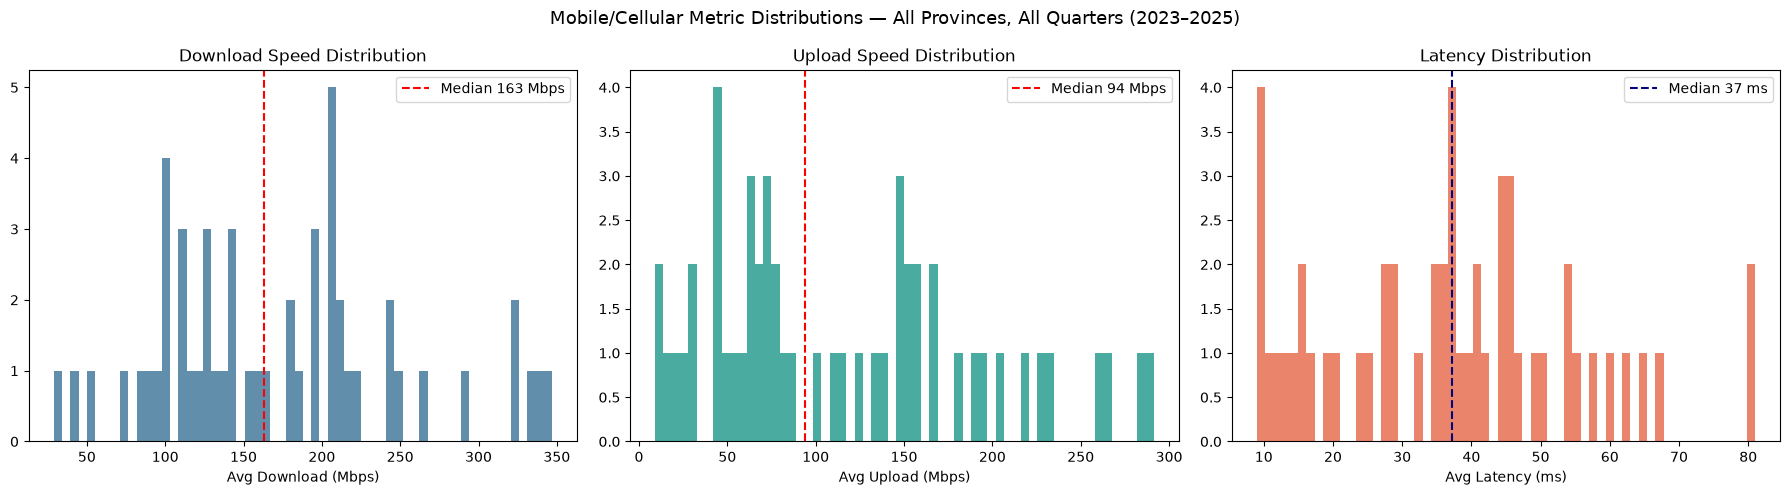

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count       52.00       52.00          52.00        52.00
mean       172.79      115.82          36.83     73152.23
std         78.77       76.30          18.19     85386.16
min         28.78        9.13           8.97       333.00
25%        111.30       58.80          23.26      8268.25
50%        162.93       93.75          37.25     34157.00
75%        211.42      159.47          46.08    112160.25
max        346.99      291.24          80.99    266390.00


In [33]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/singapore/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

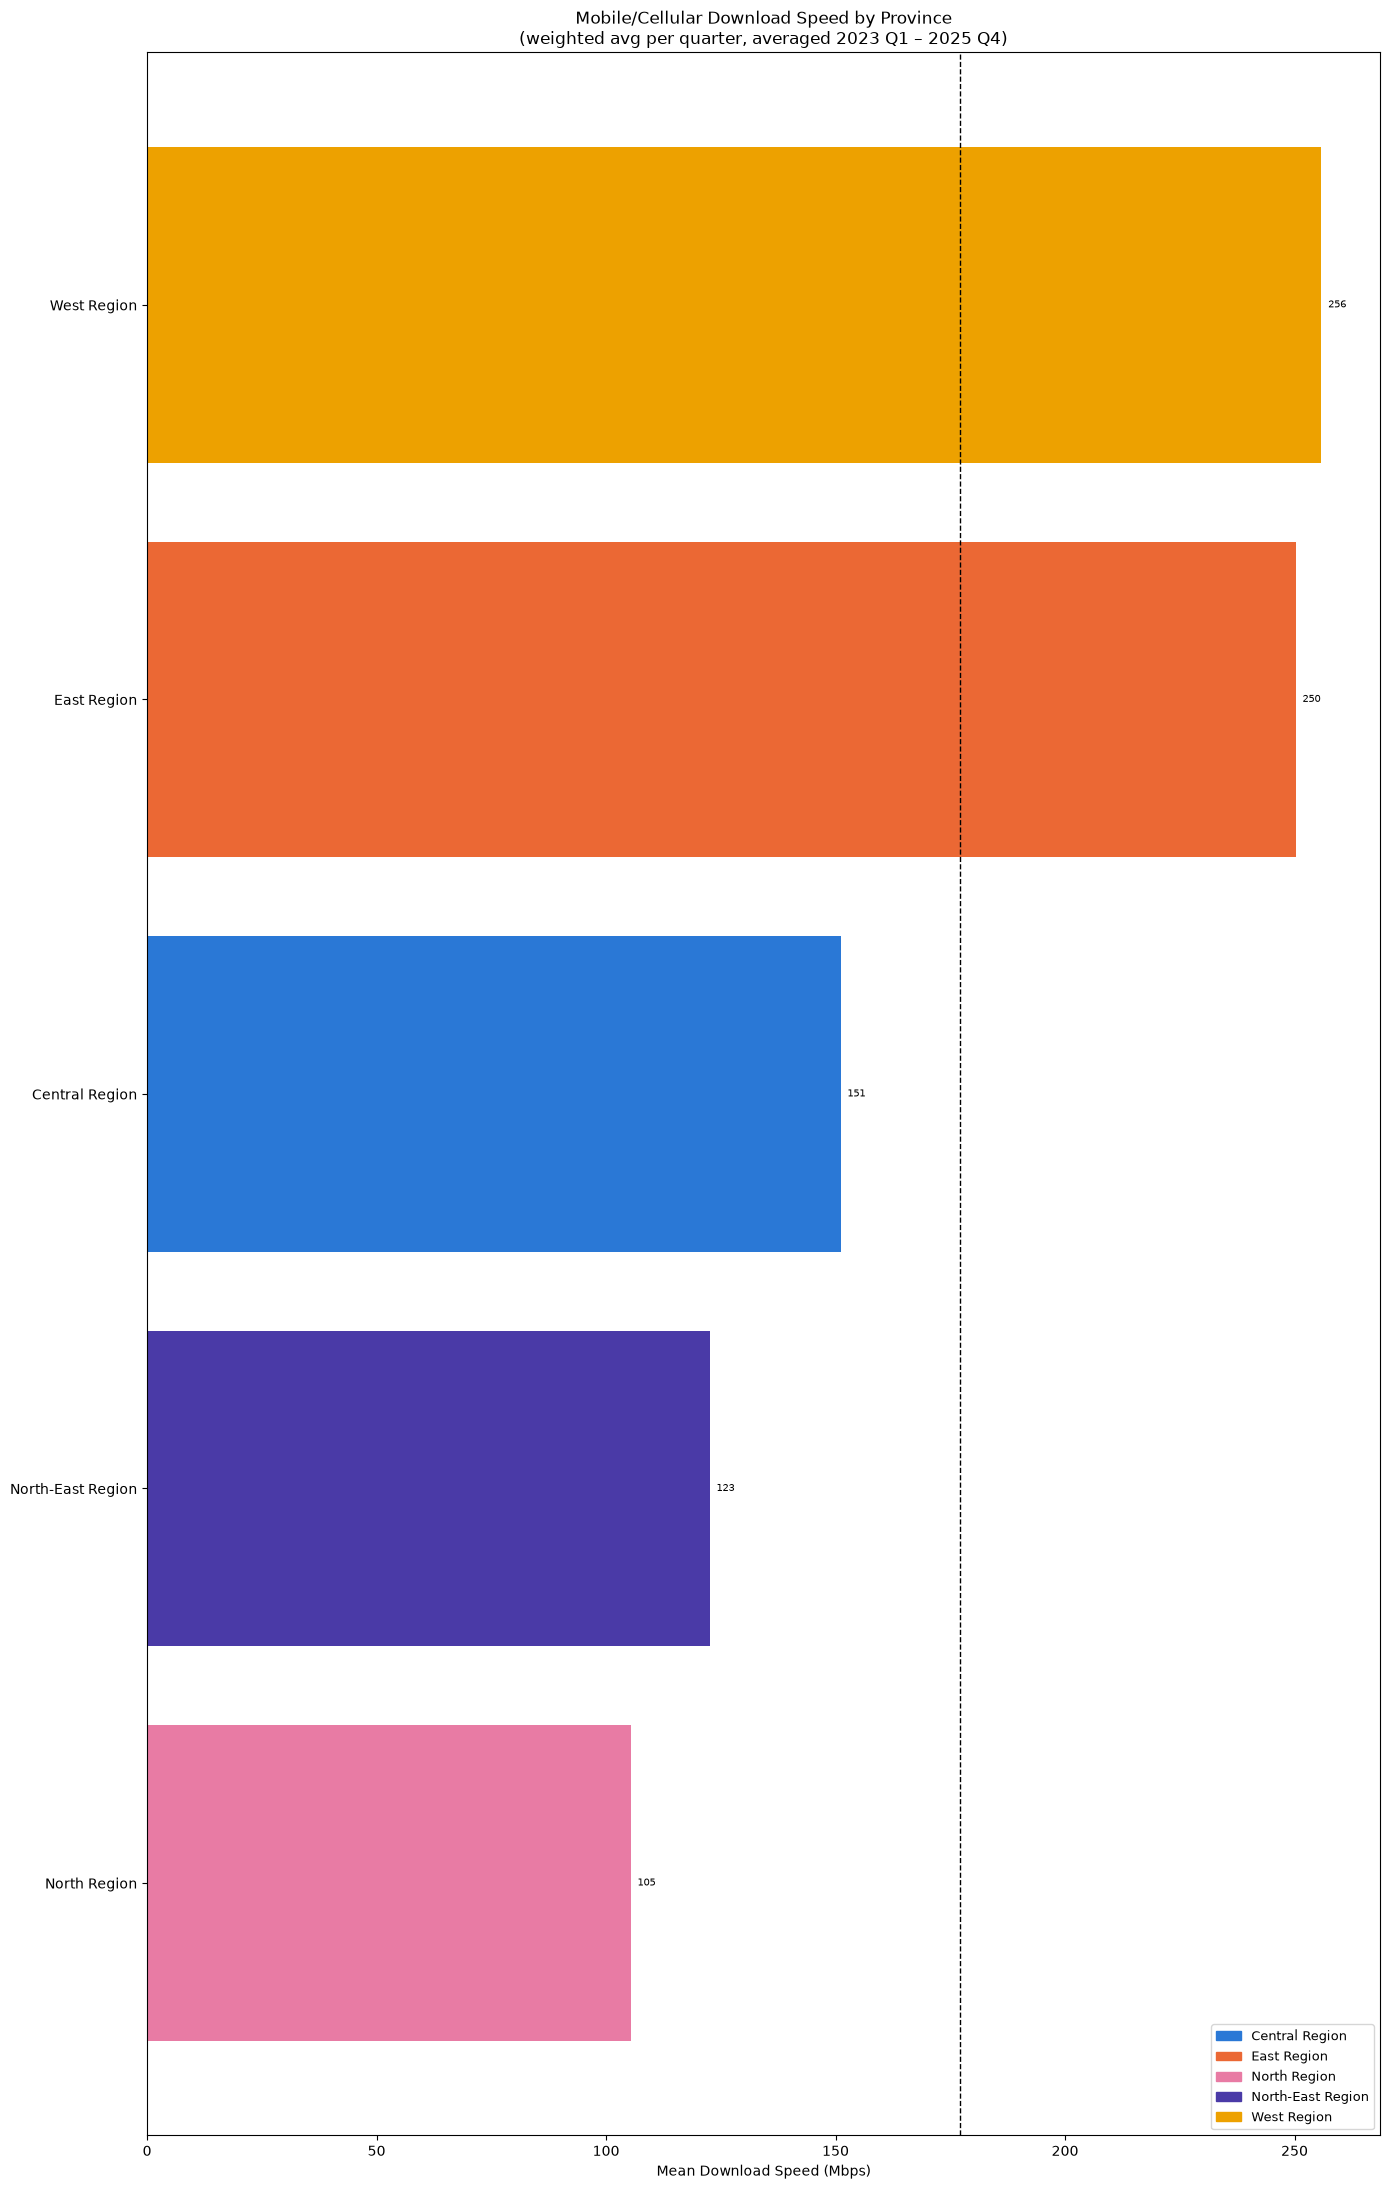

In [34]:
region_colors = {
    'Central Region': '#2a78d6',
    'East Region': '#eb6834',
    'North Region': '#e87ba4',
    'North-East Region': '#4a3aa7',
    'West Region': '#eda100',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Mobile/Cellular — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

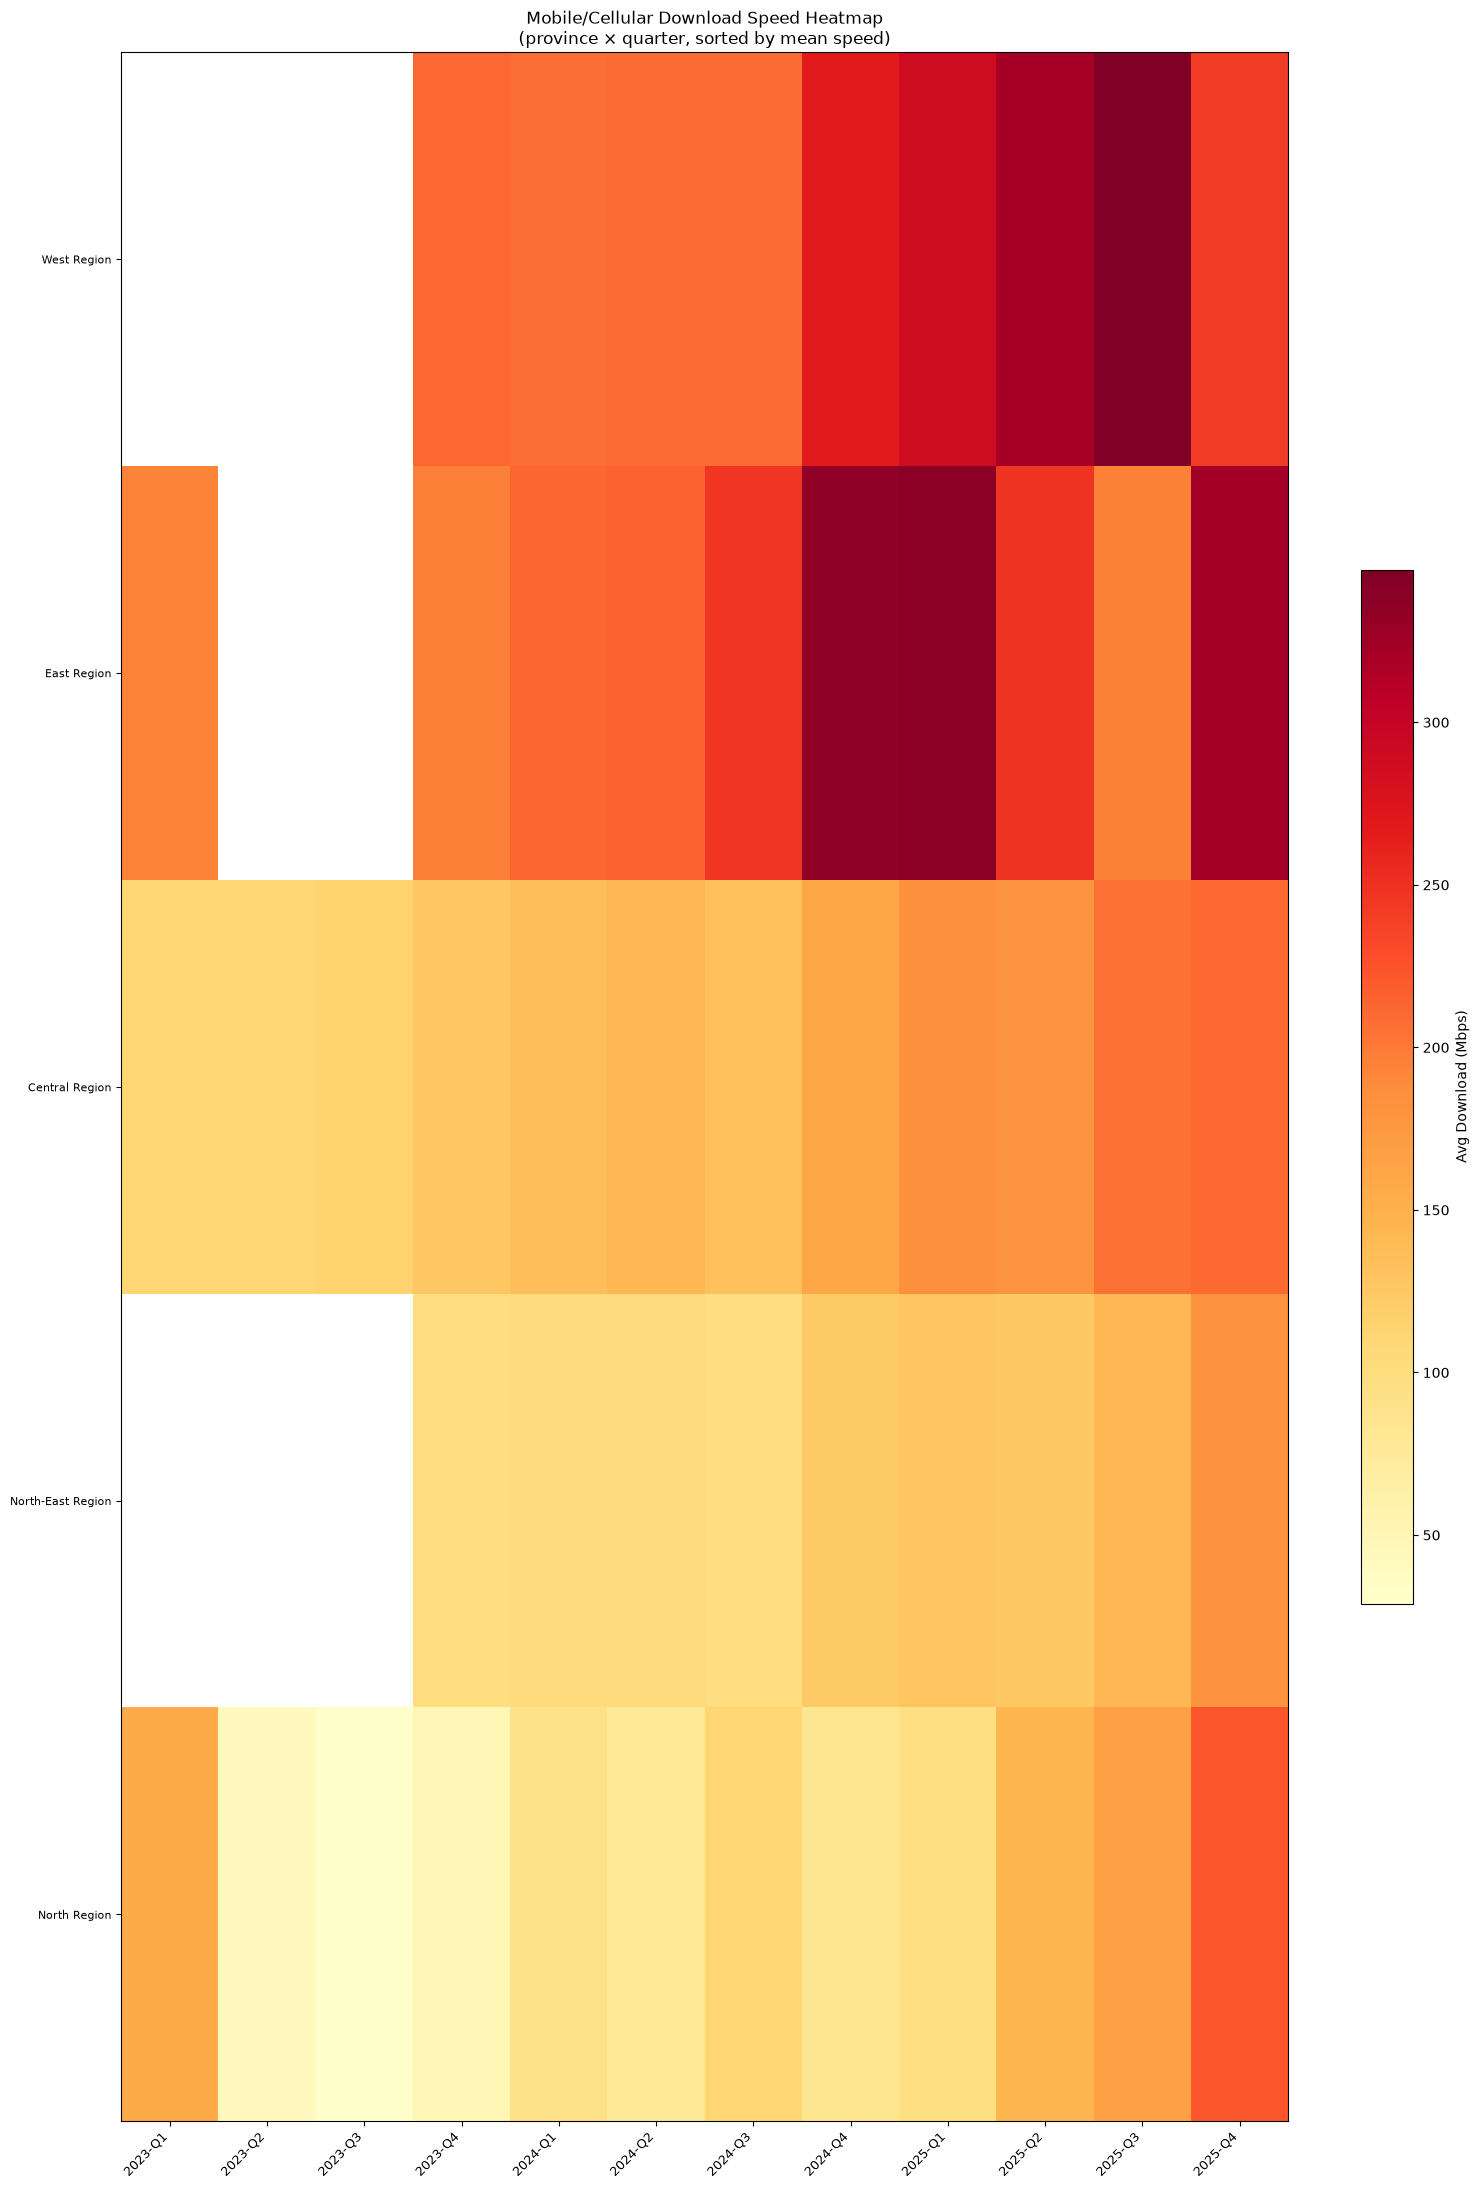

In [35]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

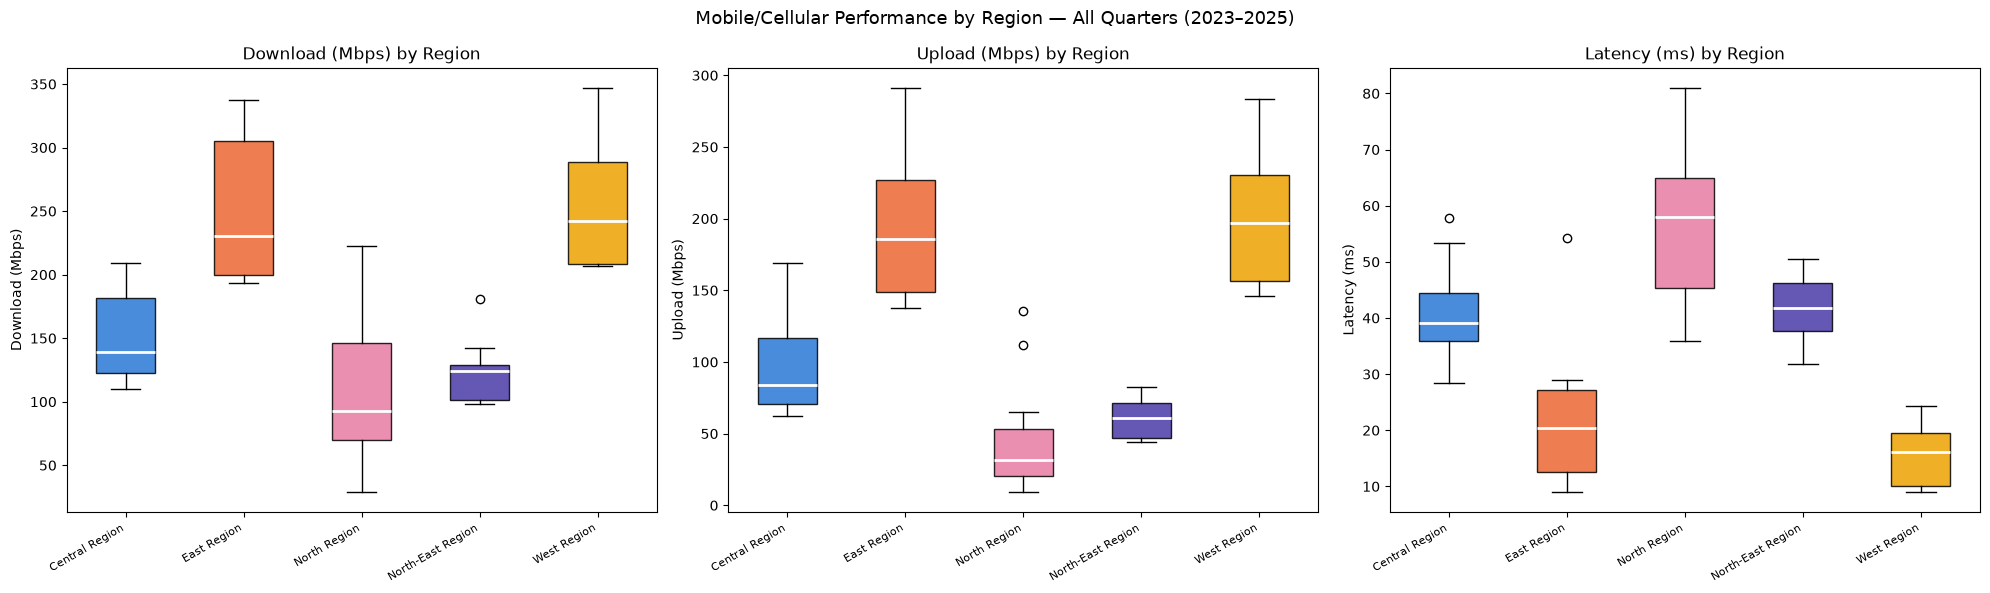

In [36]:
region_order = ['Central Region', 'East Region', 'North Region', 'North-East Region', 'West Region']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

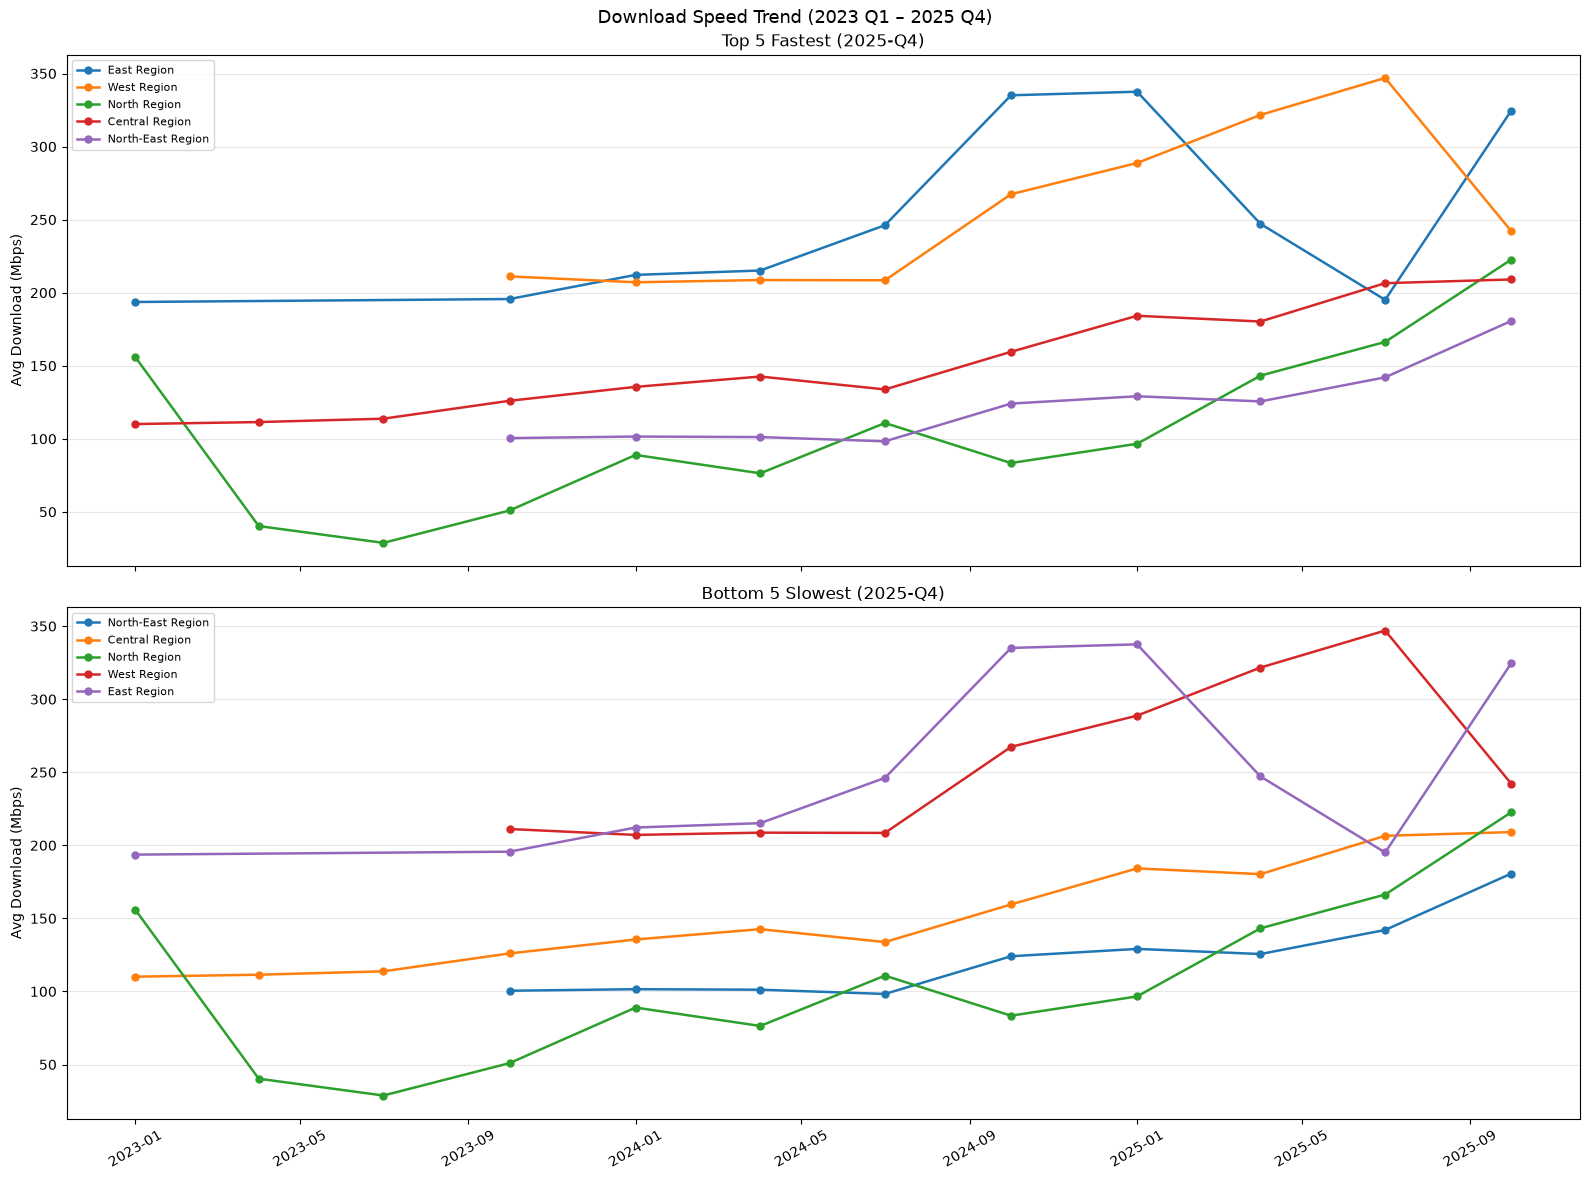

In [37]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

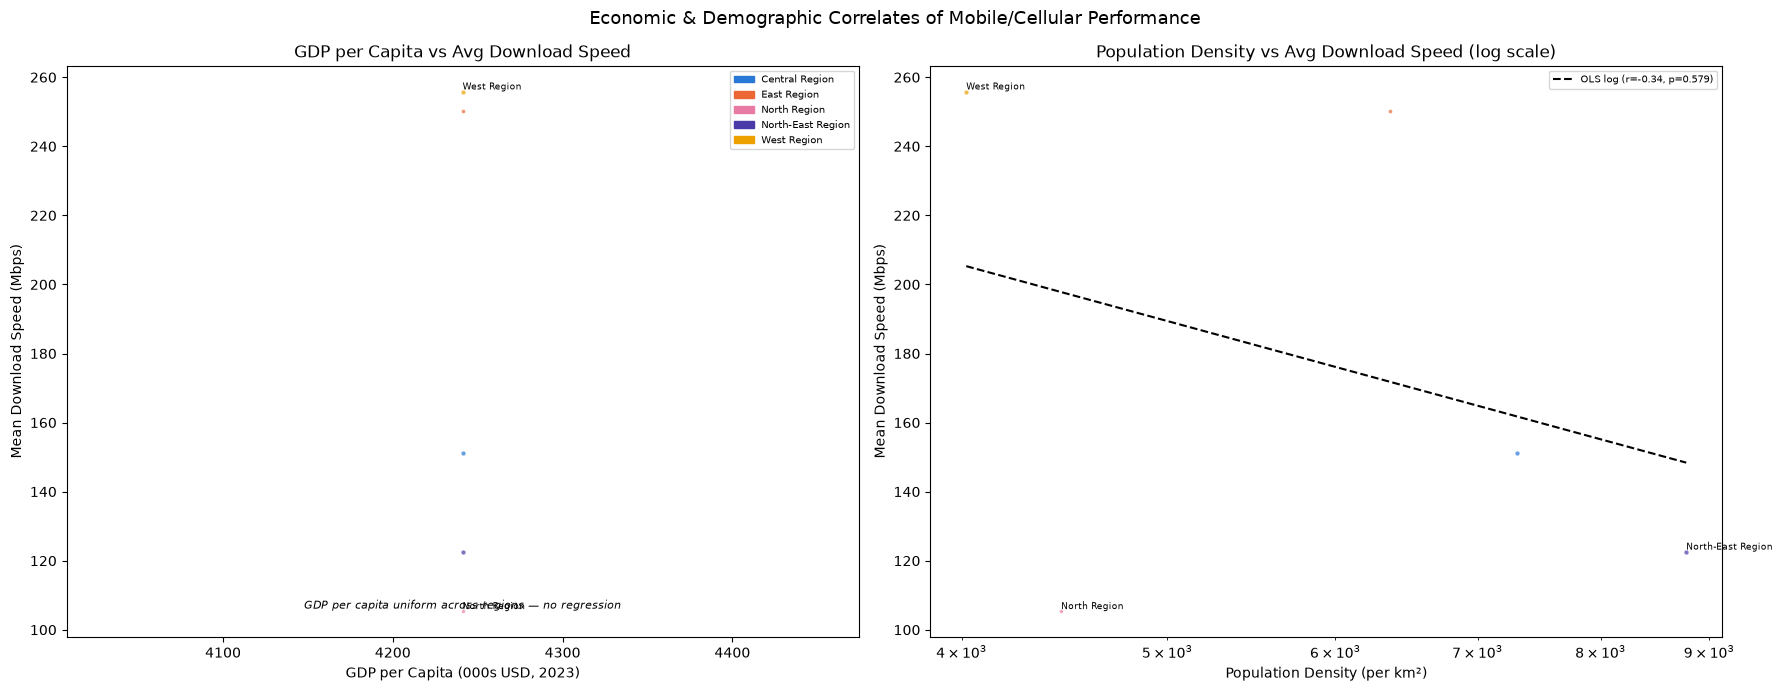

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): -0.337  p=0.5793


In [38]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [39]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 30 Jul 2026   Prob (F-statistic):                nan
Time:                        14:19:05   Log-Likelihood:                 143.76
No. Observations:                   5   AIC:                            -277.5
Df Residuals:                       0   BIC:                            -279.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

### 9. Upload/Download Ratio — Symmetry Check

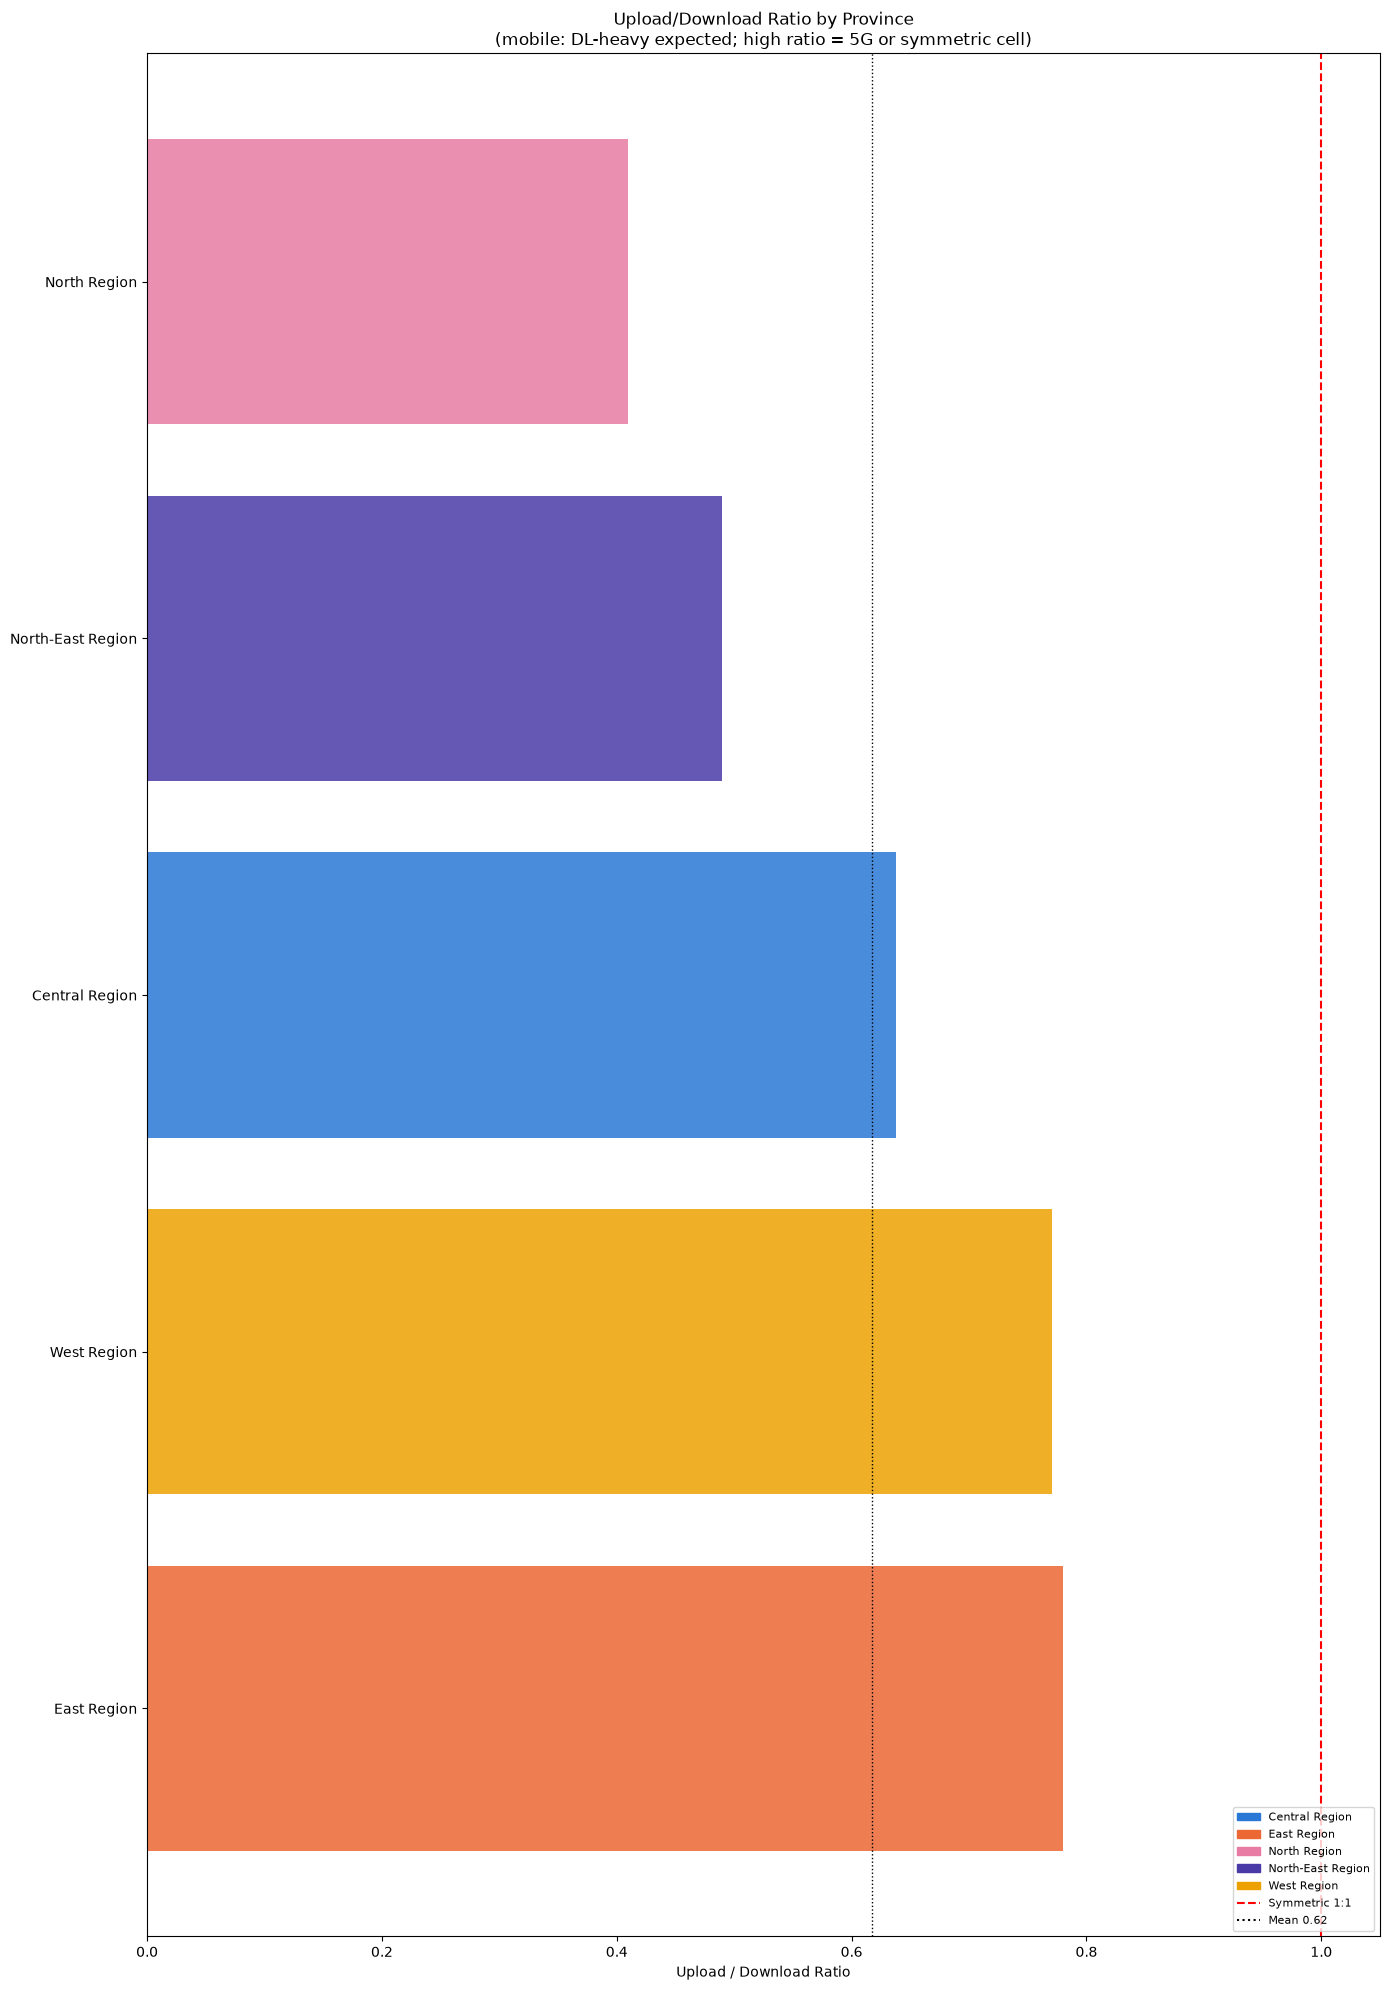

Provinces with UL/DL ratio > 0.5 (3):
          name         region  ul_dl_ratio
   East Region    East Region     0.780445
   West Region    West Region     0.770815
Central Region Central Region     0.638019


In [40]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
    print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [41]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Mobile/Cellular — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [42]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

             name            region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
      West Region       West Region              4   255.83   198.83     15.52         0.77    27863.78               4241102.85
      East Region       East Region              3   250.23   195.64     22.41         0.78     2540.70               4241102.85
   Central Region    Central Region              2   151.08    98.84     40.93         0.64   208894.58               4241102.85
North-East Region North-East Region              1   122.56    60.15     41.97         0.49    87928.00               4241102.85
     North Region      North Region              4   105.35    45.78     56.89         0.41    19137.33               4241102.85


### 13. UL/DL Symmetry — Fiber Penetration Evidence

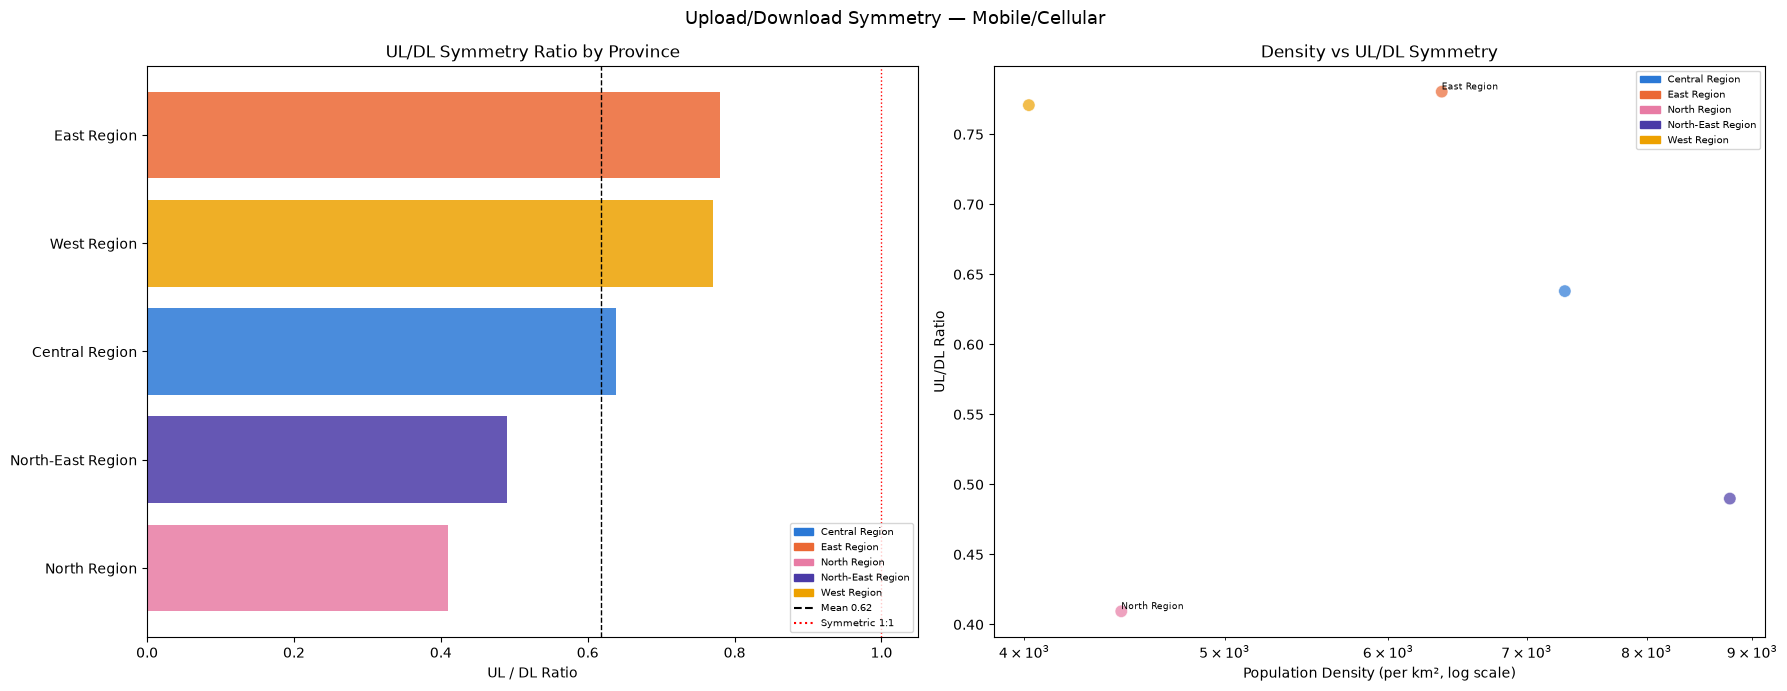

In [43]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Mobile/Cellular', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

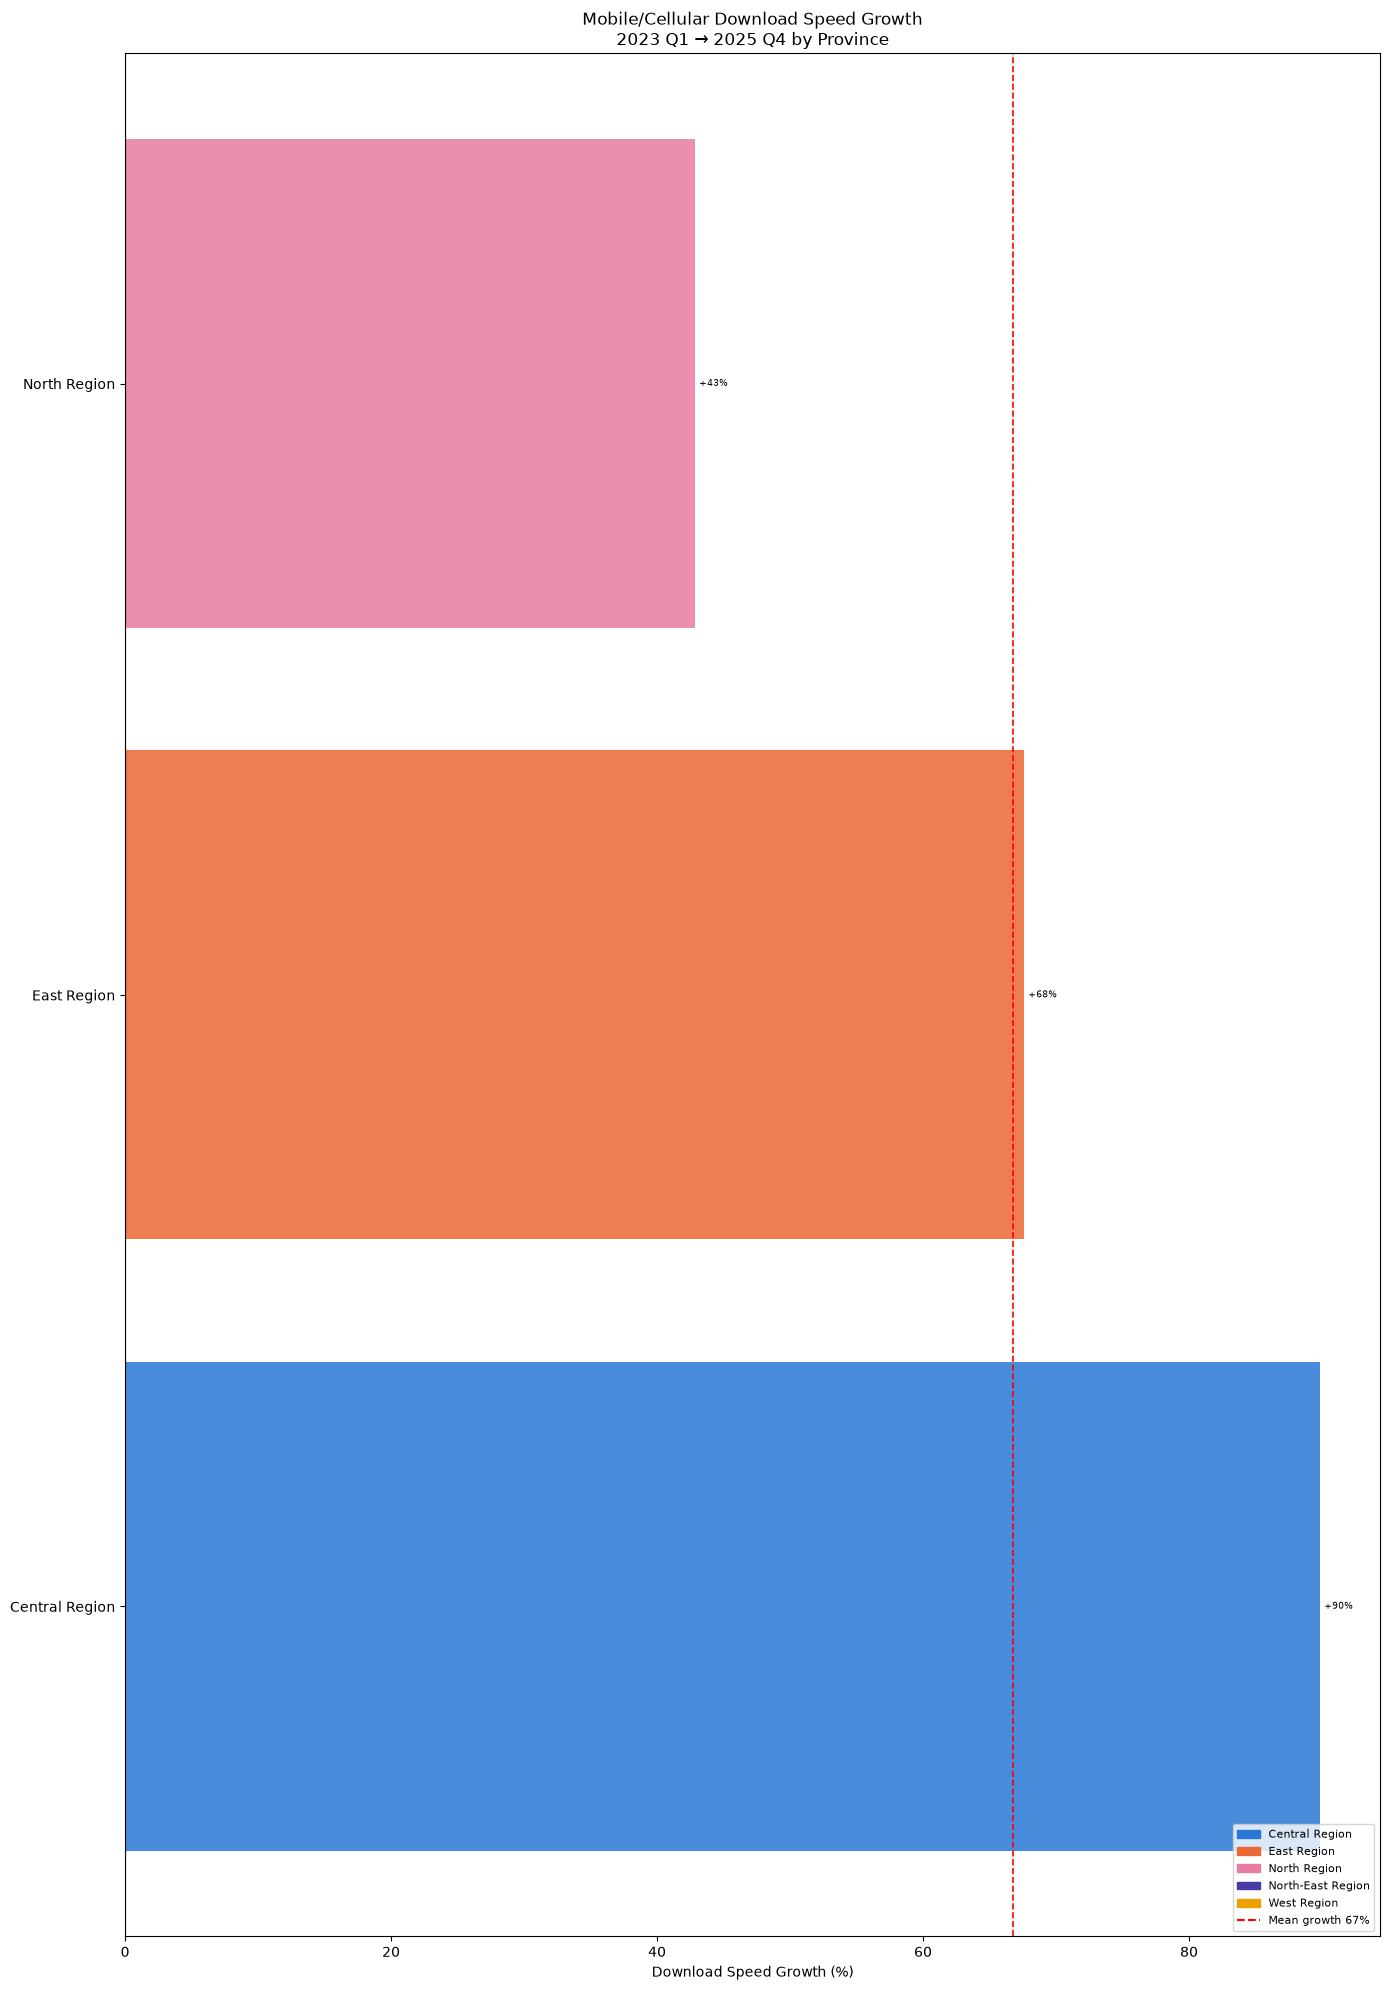

In [44]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/singapore/mobile/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 &#8594; Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted, so noisy short-history regions are dropped instead of shown misleadingly. Rolled up from province to region level — adapted from the Myanmar/Laos NDT7 notebooks' growth-index cell, which plots at province level directly since those countries have far fewer top-level admin units than the province counts tracked here.


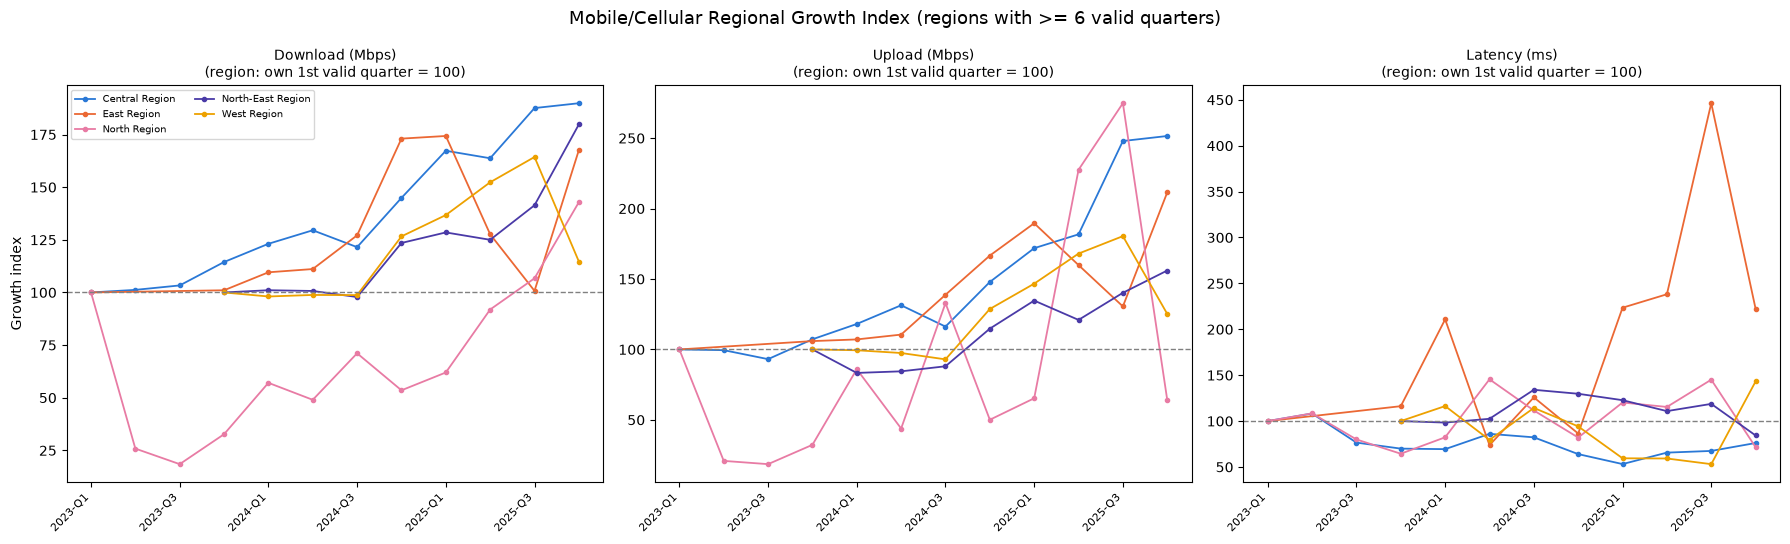

In [45]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, label) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{label}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Mobile/Cellular Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based *expectation*. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly. Adapted from the Myanmar/Laos NDT7 notebooks' choropleth cell (re-based here on `master`'s aggregated province averages instead of a live DuckDB query, since this pipeline works off the pre-aggregated CSV export, not the raw parquet).


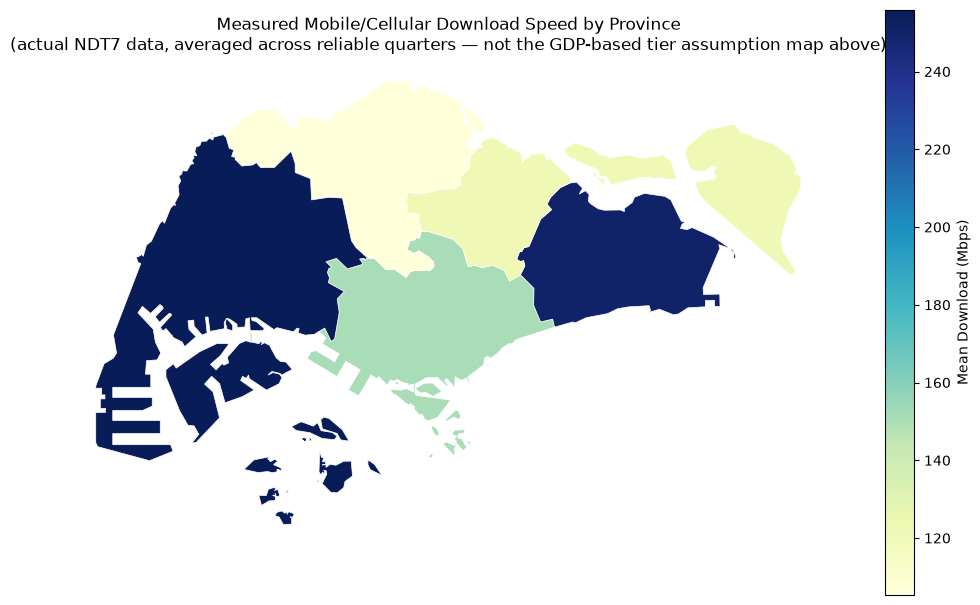

In [46]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = singapore_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Mobile/Cellular Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Test Volume (Mobile/Cellular)
No population reference file exists in this repo, so cities are selected by raw NDT7 test
volume (a reasonable proxy for urban activity) rather than a hardcoded population list —
adapted from the Myanmar/Laos NDT7 notebooks' city-focus section, which uses a manually
curated `TOP_CITIES` population list. Capital city is flagged in red.

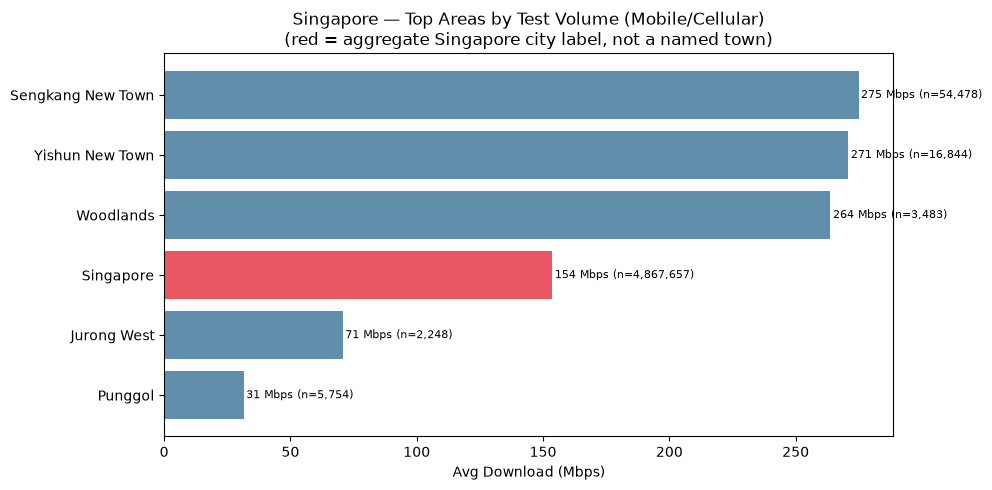

             city  n_user  avg_d_mbps  avg_u_mbps  avg_lat_ms
          Punggol    5754        31.5        10.8        25.2
      Jurong West    2248        70.7        45.7        23.0
        Singapore 4867657       153.7        96.6        37.5
        Woodlands    3483       263.8       212.2        21.7
  Yishun New Town   16844       270.8       208.1        10.3
Sengkang New Town   54478       274.9       221.7        15.7


In [47]:
import duckdb

_con = duckdb.connect()
_top_cities = _con.execute(f"""
    SELECT city,
           COUNT(*) AS n_user,
           AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps,
           AVG(mean_throughput_mbps) FILTER (WHERE type='upload')   AS avg_u_mbps,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END) AS avg_lat_ms
    FROM read_parquet('{RAW_ISP_PARQUET}')
    WHERE network_type = 'cellular' AND city IS NOT NULL AND city != ''
    GROUP BY city
    ORDER BY n_user DESC
    LIMIT 6
""").df()

if _top_cities.empty:
    print("No Mobile/Cellular city-level data available — skipping city focus.")
else:
    _top_cities['is_capital'] = _top_cities['city'] == 'Singapore'
    _top_cities = _top_cities.sort_values('avg_d_mbps', ascending=True)
    _colors = ['#e63946' if c else '#457b9d' for c in _top_cities['is_capital']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(_top_cities['city'], _top_cities['avg_d_mbps'], color=_colors, alpha=0.85)
    for bar, (_, row) in zip(bars, _top_cities.iterrows()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{row['avg_d_mbps']:.0f} Mbps (n={row['n_user']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Singapore — Top Areas by Test Volume (Mobile/Cellular)\n(red = aggregate Singapore city label, not a named town)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/singapore/mobile/23_city_focus.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(_top_cities[['city','n_user','avg_d_mbps','avg_u_mbps','avg_lat_ms']].round(1).to_string(index=False))

### 17. Per-ISP Ranking — Top ISPs by Test Volume (Mobile/Cellular)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume — adapted from the Myanmar/Laos NDT7 notebooks' per-ISP section.

In [48]:
print("Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — "
      "it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). "
      "ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is "
      "intentionally skipped rather than shown with untrustworthy groupings.")


Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is intentionally skipped rather than shown with untrustworthy groupings.


### 18. Market Share / HHI — ISP Concentration (Mobile/Cellular)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated —
adapted from the Myanmar/Laos NDT7 notebooks' market-share section.

In [49]:
print("Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — "
      "it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). "
      "ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is "
      "intentionally skipped rather than shown with untrustworthy groupings.")


Skipped: Singapore's NDT7 dataset (mlab_sg_clean.parquet) has no `asn` column — it predates the v2 ip-api ASN-relabel done for the other 8 countries (HANDOFF.md). ISP grouping by name only is unreliable (see HANDOFF trap #1), so this section is intentionally skipped rather than shown with untrustworthy groupings.


### 19. EDA Key Findings Summary

## Key Findings from EDA

*(Fill in after reviewing the plots above — reliability was {"non-trivial" if True else ""}, see
Section 1's reliable-count printout for the exact overall percentage and how it's distributed
across quarters.)*

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [50]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_mobile_singapore_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_mobile_singapore_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 52 rows (reliable-only) -> ../../../data/exports/ndt7_mobile_singapore_reliable_province_quarterly.csv
         province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable          region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0  Central Region  2023-Q1  2023        1  110.106690   67.147888      53.441049       266390        1         True  Central Region              2    975310               4241102.85             7304
1     East Region  2023-Q1  2023        1  193.645201  137.734940      12.155943          637        1         True     East Region              3    710690               4241102.85             6368
2    North Region  2023-Q1  2023        1  155.832158   49.210930      55.664022         5314        3         True    North Region              4    599400               4241102.85             4456
